# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [3]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`# used linux to download

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3844213997.py, line 1)

In [1]:
!rm SUSY.csv

rm: cannot remove 'SUSY.csv': No such file or directory


In [2]:
!gunzip SUSY.csv.gz

In [3]:
ls -lh

total 2.3G
-rwxrwxrwx 1 maryam maryam 390K Mar 21 17:06 Lab.7-Irfan.ipynb*
-rwxrwxrwx 1 maryam maryam 2.3G Mar 21 17:10 SUSY.csv*


The data is provided as a comma separated file.

In [31]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 2.3G
-rwxrwxrwx 1 maryam maryam 390K Mar 21 17:06 Lab.7-Irfan.ipynb
-rwxrwxrwx 1 maryam maryam 2.3G Mar 21 17:10 SUSY.csv


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

In [9]:
ls -lh

total 2.5G
-rwxrwxrwx 1 maryam maryam 389K Mar 21 17:13 Lab.7-Irfan.ipynb*
-rwxrwxrwx 1 maryam maryam 228M Mar 21 17:13 SUSY-small.csv*
-rwxrwxrwx 1 maryam maryam 2.3G Mar 21 17:10 SUSY.csv*


In [10]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [32]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [33]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [34]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [35]:
FeatureNames

['MET_rel',
 'axial_MET',
 'R',
 'dPhi_r_b',
 'S_R',
 'M_R',
 'M_TR_2',
 'MT2',
 'M_Delta_R',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [37]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [18]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [38]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


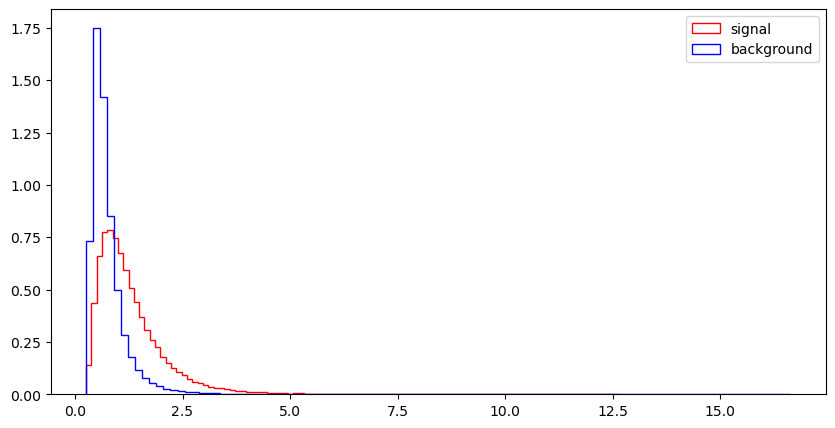

l_1_eta


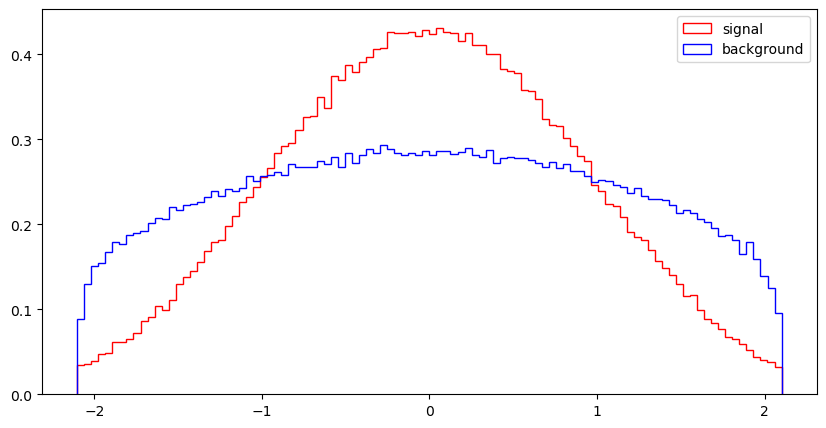

l_1_phi


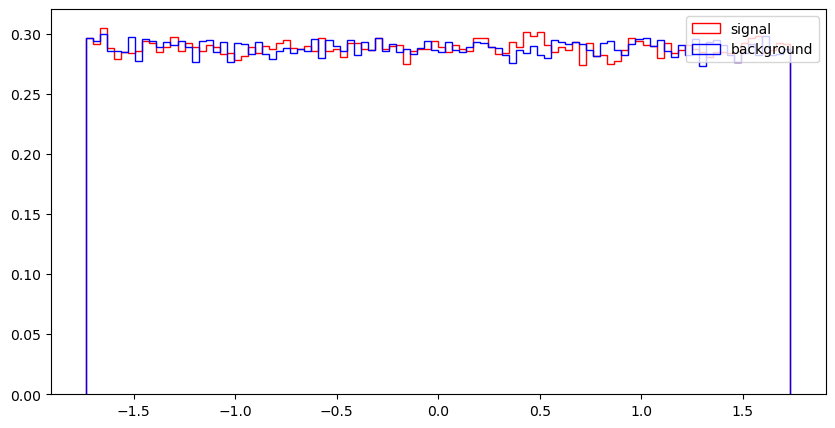

l_2_pT


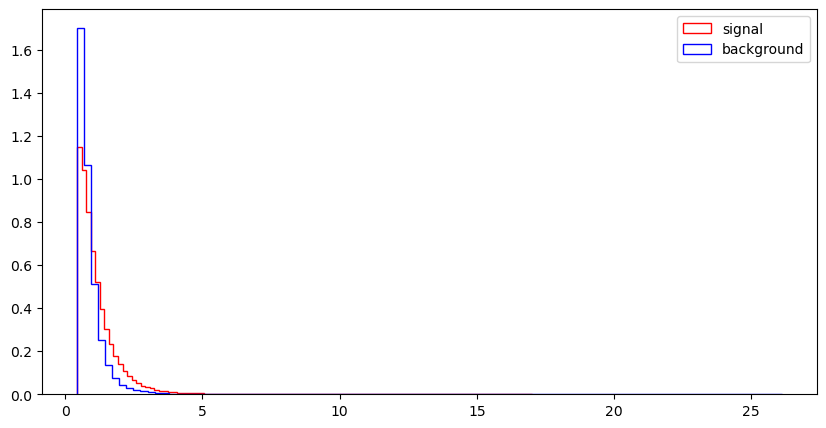

l_2_eta


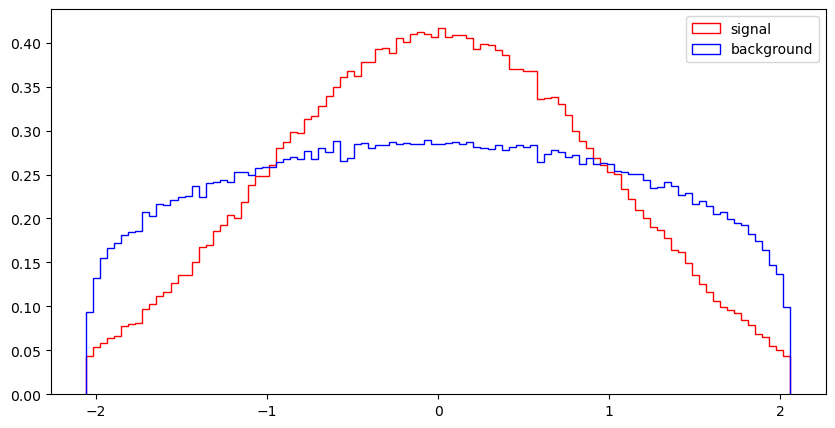

l_2_phi


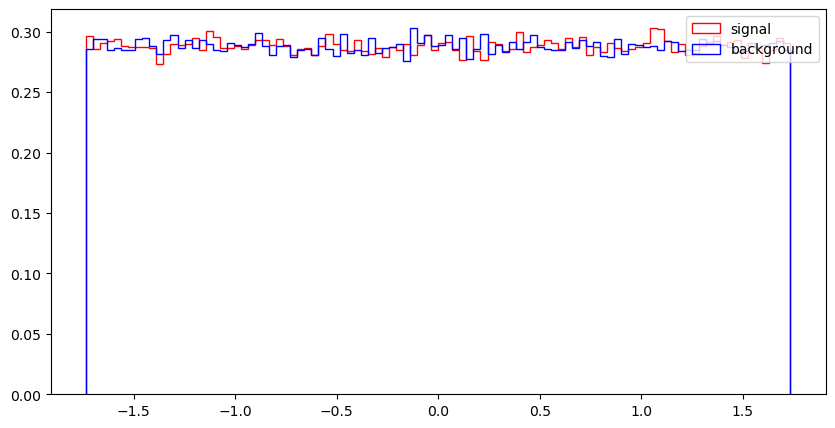

MET


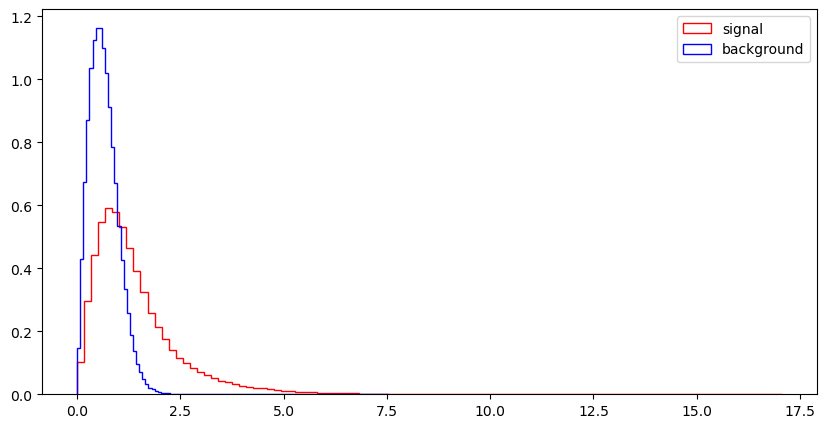

MET_phi


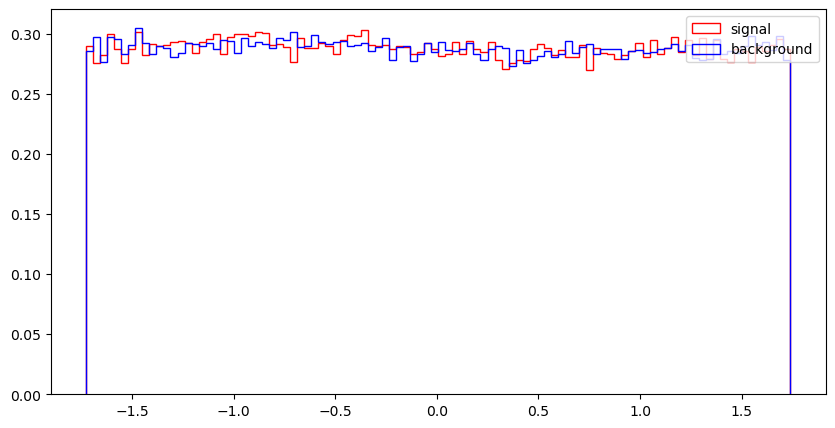

MET_rel


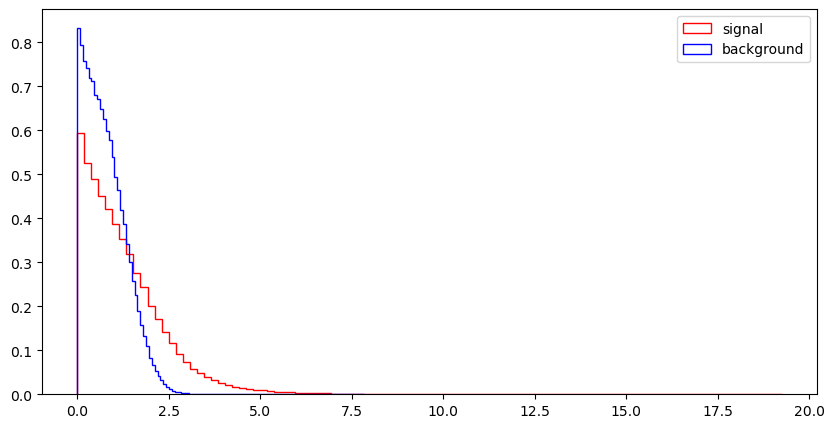

axial_MET


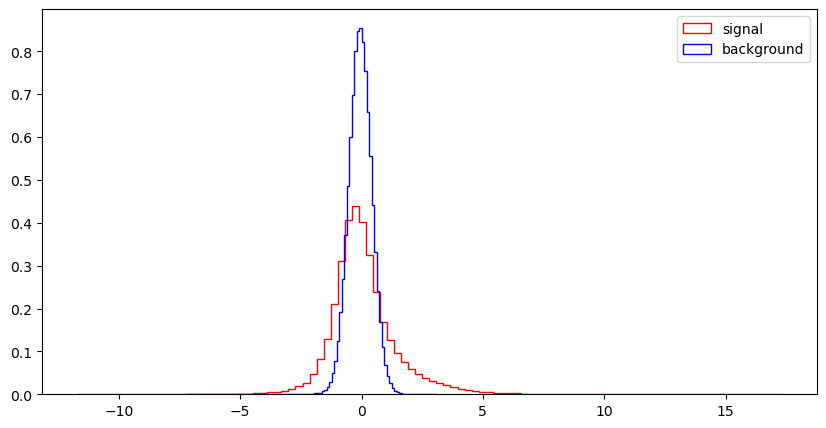

M_R


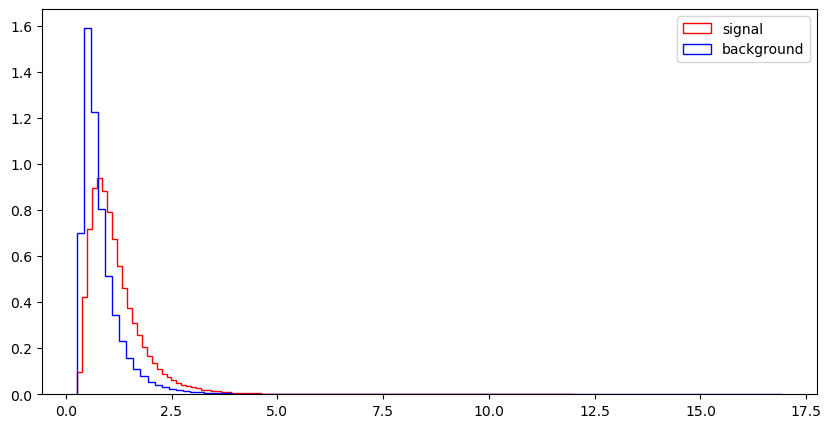

M_TR_2


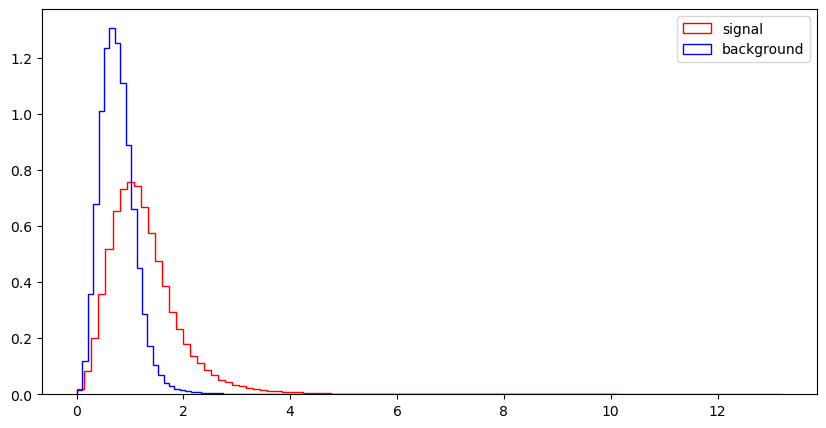

R


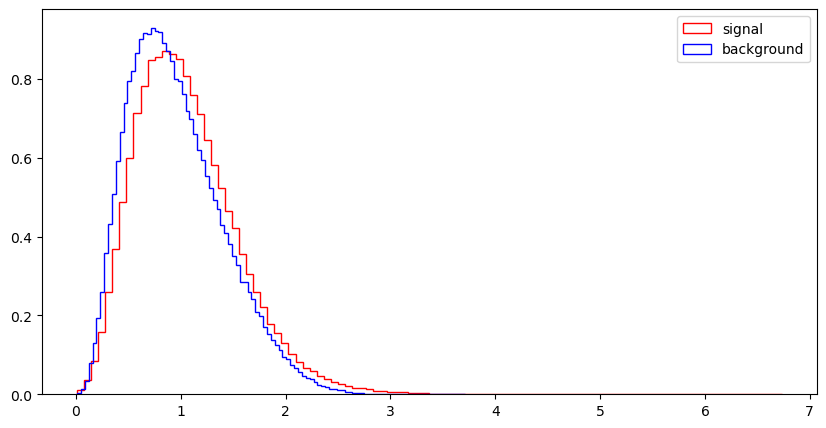

MT2


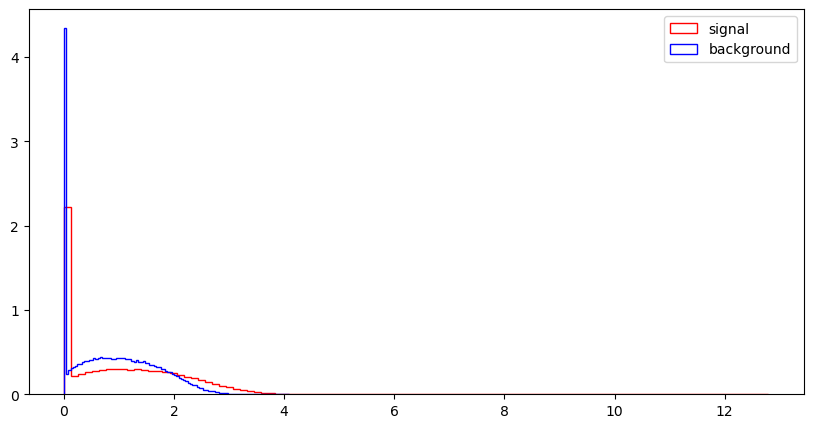

S_R


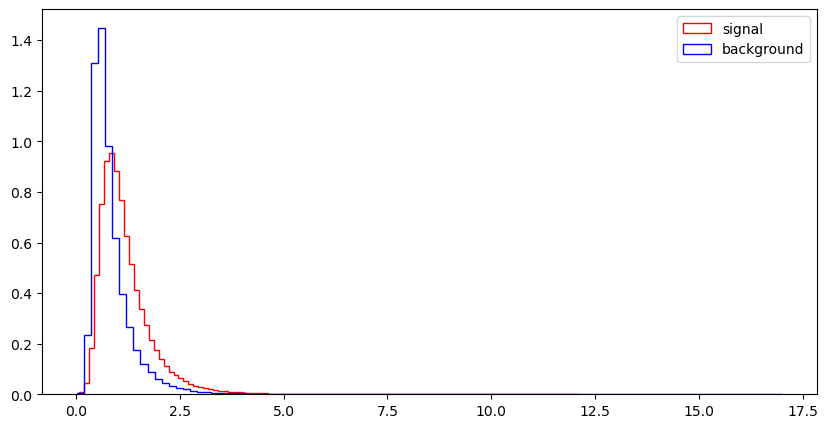

M_Delta_R


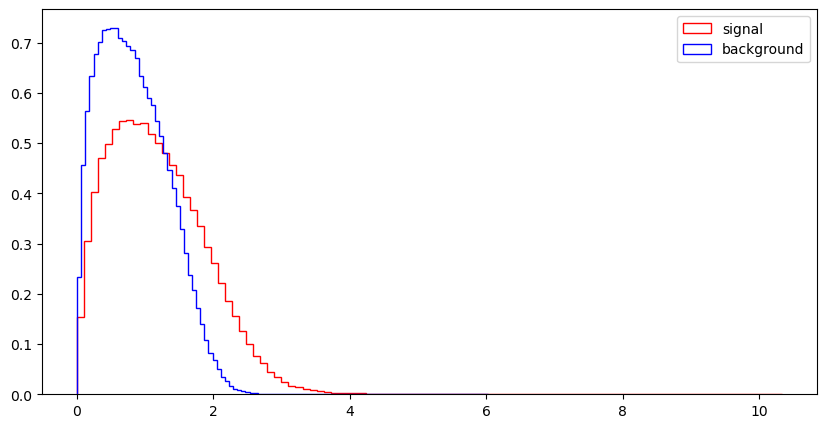

dPhi_r_b


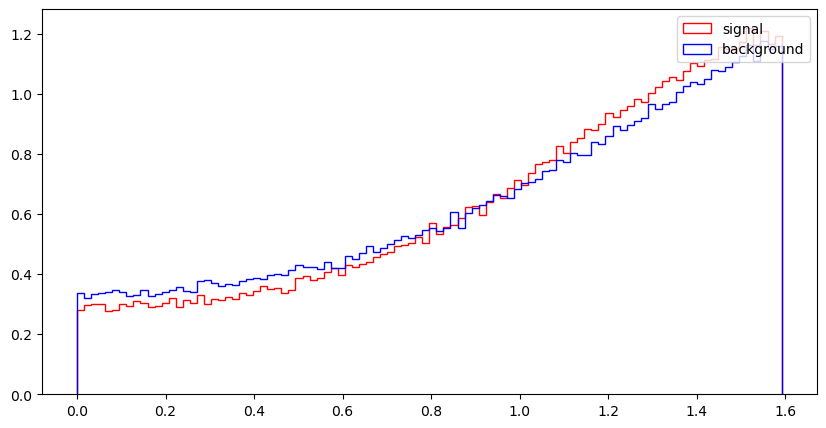

cos_theta_r1


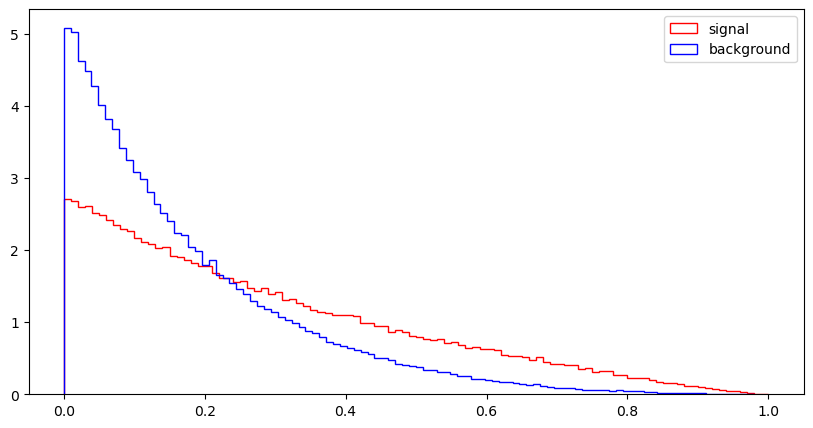

In [39]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

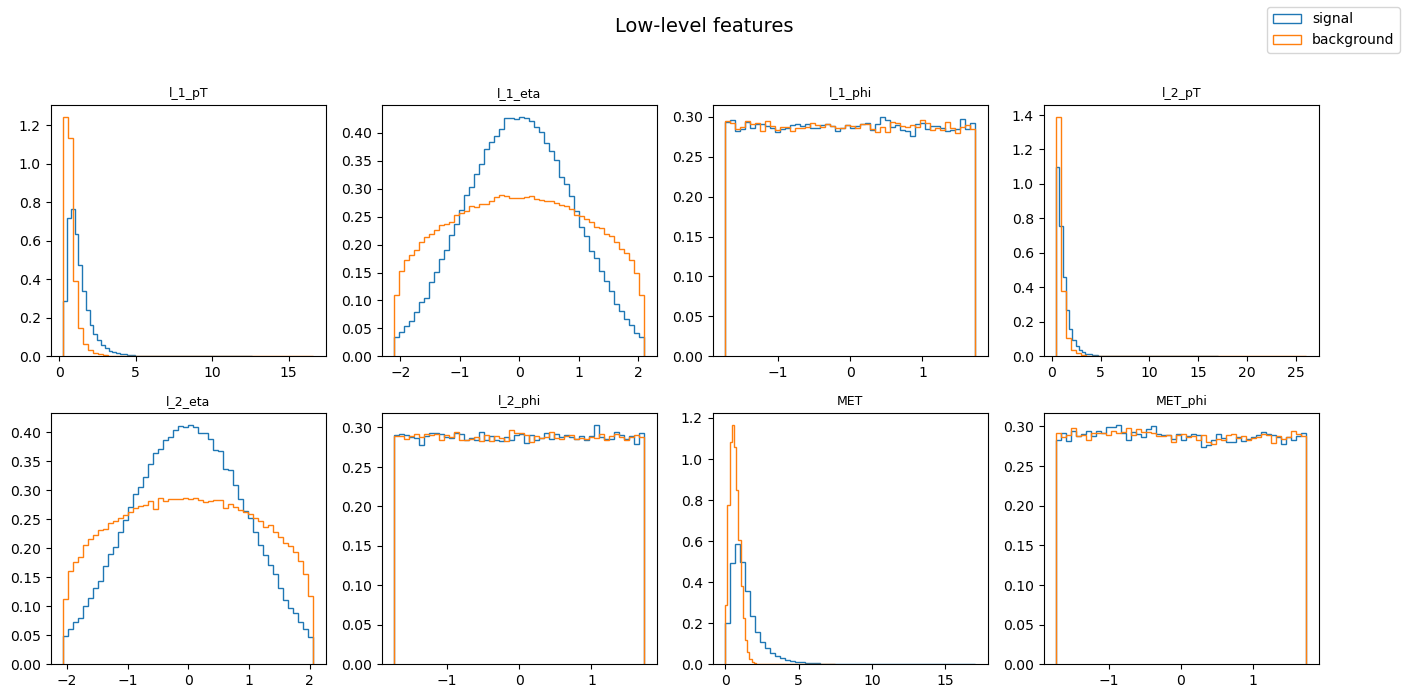

In [23]:
#Figure 5

# These are considered "low-level" features in the paper
low_level_vars = VarNames[1:9]

# I used a 2x4 grid because that's how the paper organizes them
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, var in enumerate(low_level_vars):
    ax = axes[i // 4, i % 4]
    
    # I kept bins consistent across all plots so they look uniform like the paper
    bins = 50
    
    # This makes it easier to compare shapes
    ax.hist(df_sig[var], bins=bins, histtype="step", density=True, label="signal")
    ax.hist(df_bkg[var], bins=bins, histtype="step", density=True, label="background")
    
    # I wasn’t sure at first if I should fix axis limits, but I noticed the paper keeps things consistent, 
    # so I left it auto for simplicity
    ax.set_title(var, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# One shared legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

# Adding a title to match the paper style
fig.suptitle("Low-level features", fontsize=14)

# I added tight_layout after my plots looked messy at first
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

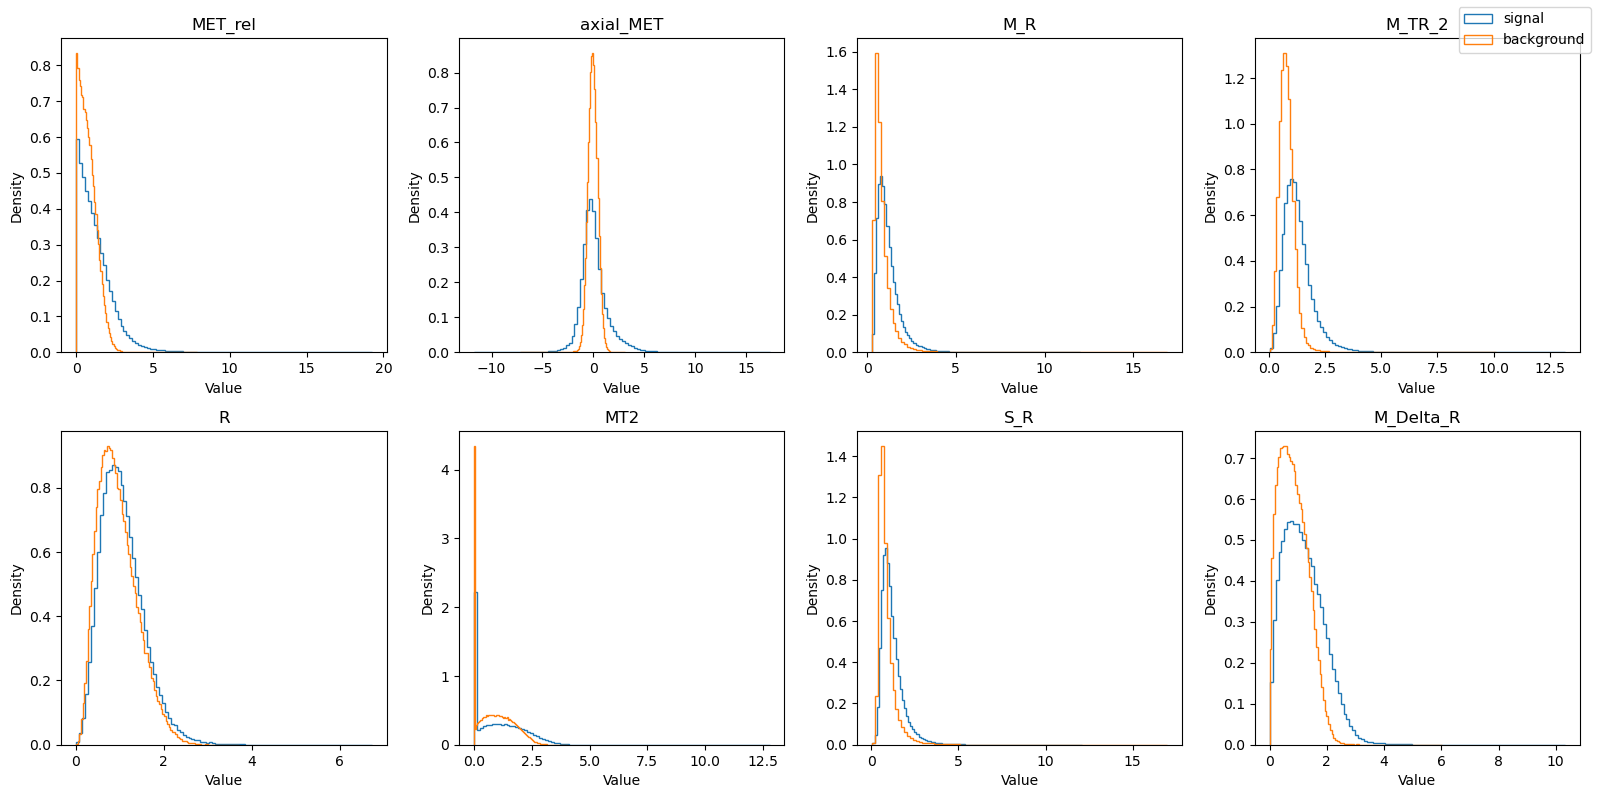

In [25]:
# Figure 6

# I just repeat the same idea for the remaining variables
vars_to_plot = VarNames[9:17]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, var in enumerate(vars_to_plot):
    ax = axes[i // 4, i % 4]
    
    ax.hist(np.array(df_sig[var]), bins=100, histtype="step", density=1, label="signal")
    ax.hist(np.array(df_bkg[var]), bins=100, histtype="step", density=1, label="background")
    
    ax.set_title(var)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

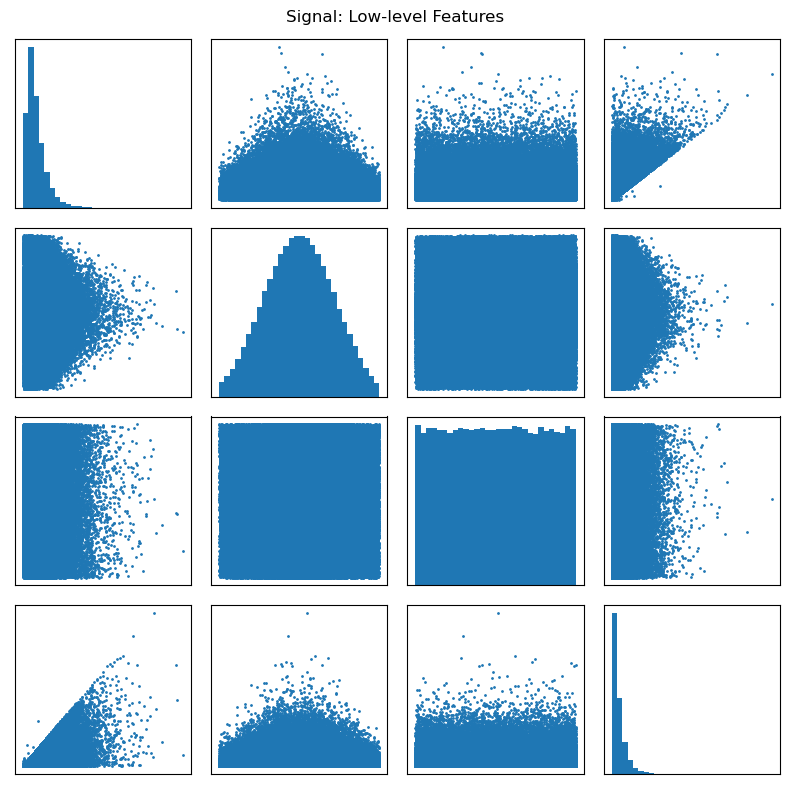

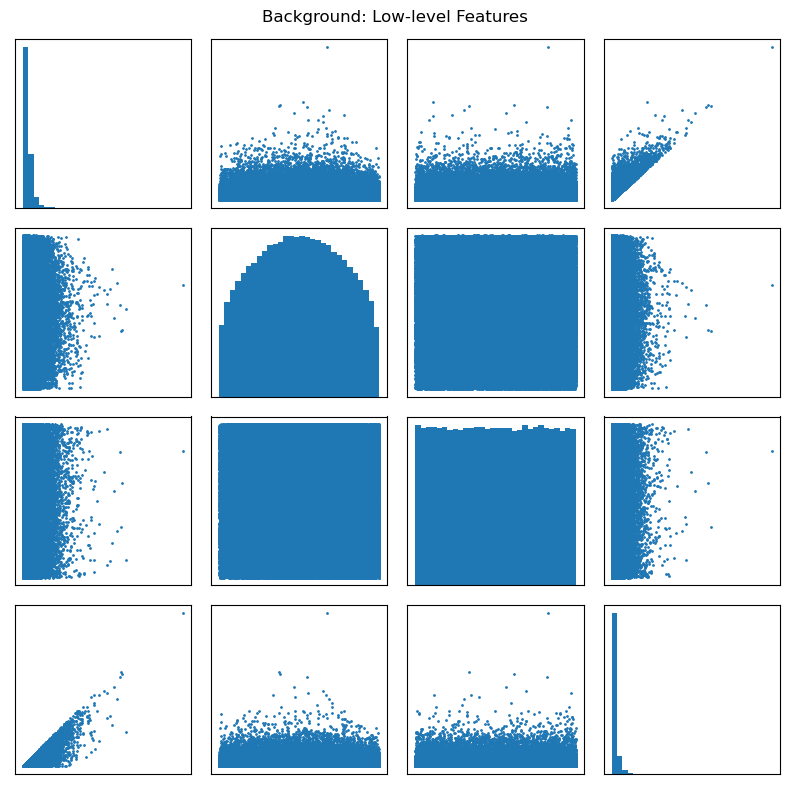

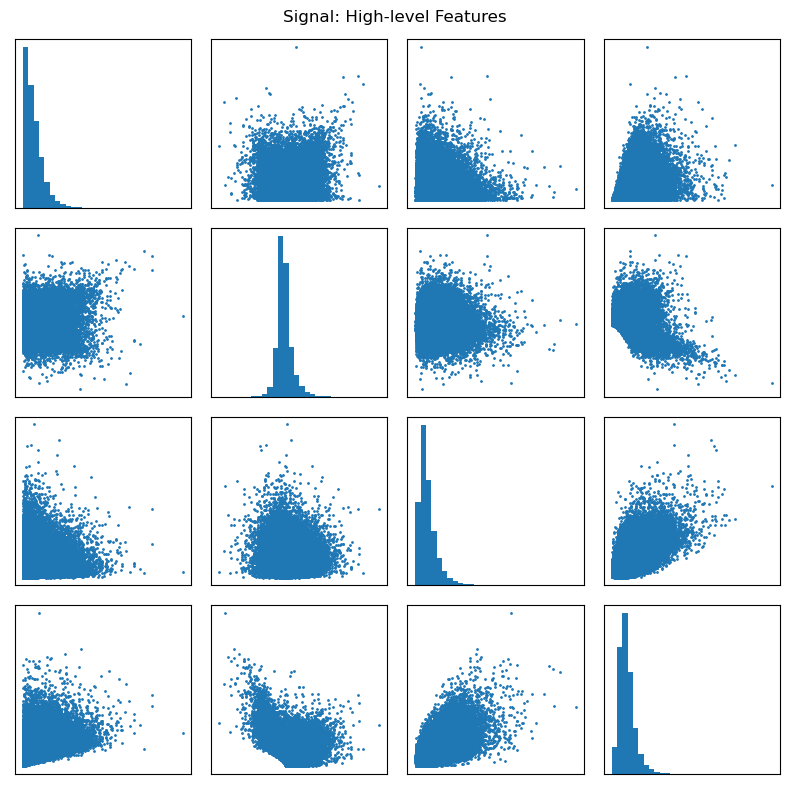

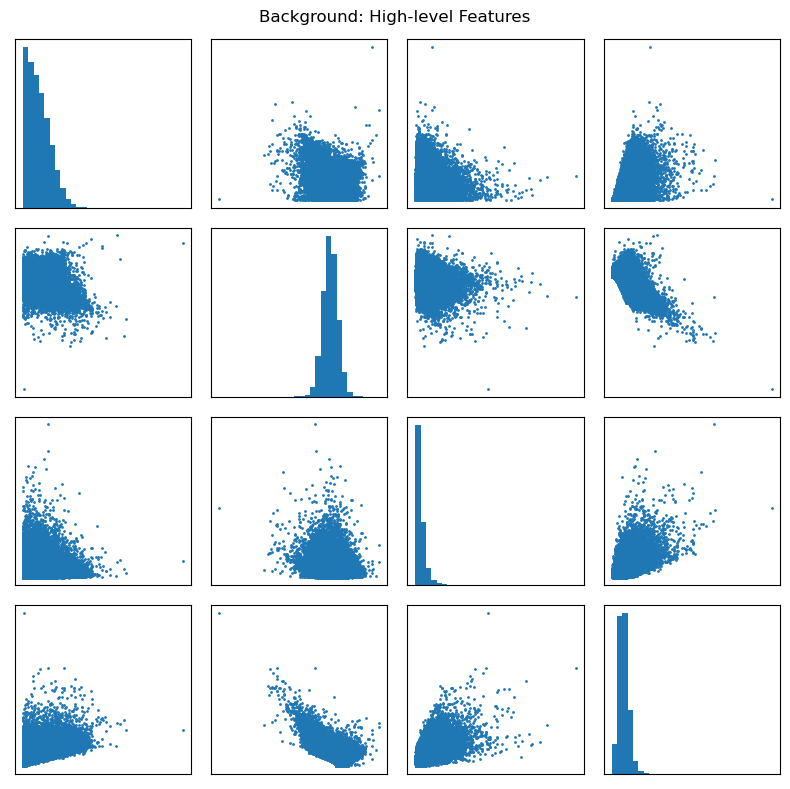

In [26]:
#Part a

def pair_plot(data, variables, title):
    
    n = len(variables)
    
    # I used a square grid (n x n) since every variable is compared with every other
    fig, axes = plt.subplots(n, n, figsize=(2*n, 2*n))
    
    # Loop through each variable combination
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            
            if i == j:
                # I used fewer bins because too many made the plots noisy and slow
                ax.hist(data[variables[i]], bins=30, density=True)
                
            else:
                # I wasn’t sure at first how dense this would be,but it turns out plotting everything works (just slow)
                ax.scatter(data[variables[j]], data[variables[i]], s=1)
            
            # Remove ticks to keep it clean (like lecture examples)
            ax.set_xticks([])
            ax.set_yticks([])
    
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Low-level features
low_vars = VarNames[1:5]  # I reduced to 4 variables because full 8x8 was too slow and cluttered
pair_plot(df_sig, low_vars, "Signal: Low-level Features")
pair_plot(df_bkg, low_vars, "Background: Low-level Features")

# High-level features
high_vars = VarNames[9:13]
pair_plot(df_sig, high_vars, "Signal: High-level Features")
pair_plot(df_bkg, high_vars, "Background: High-level Features")

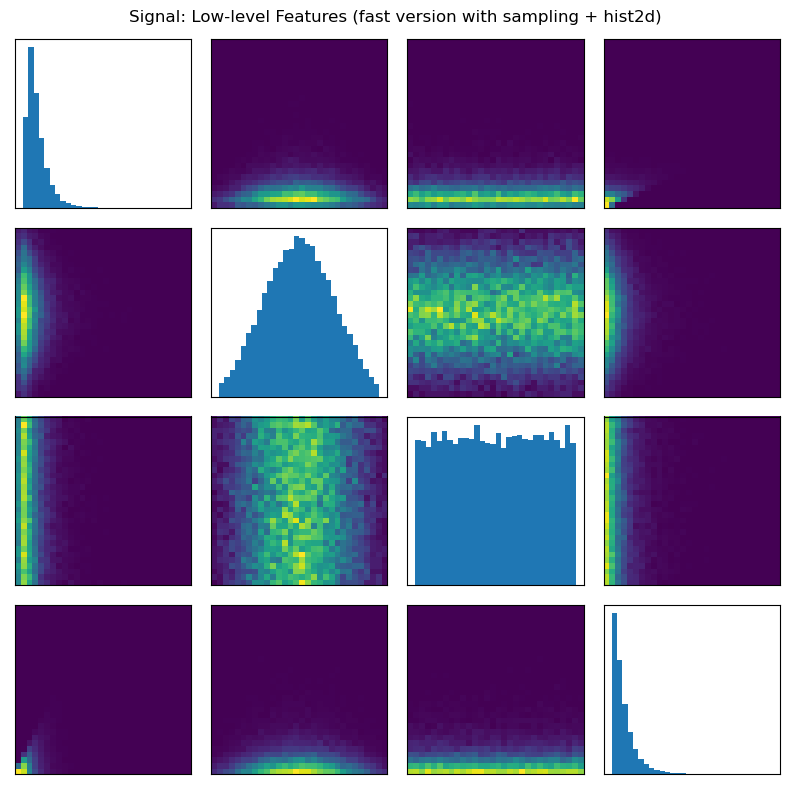

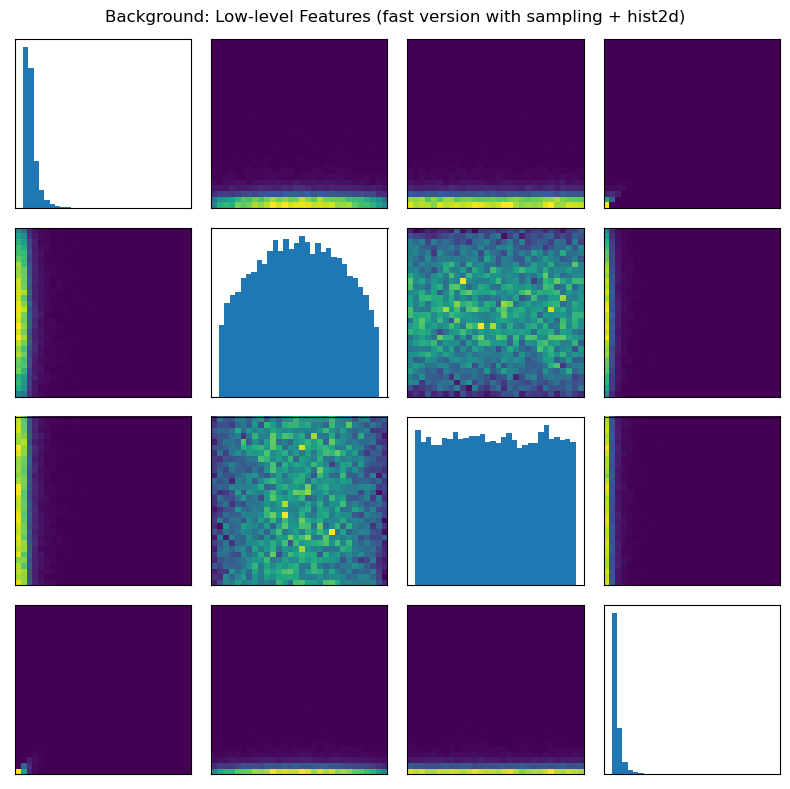

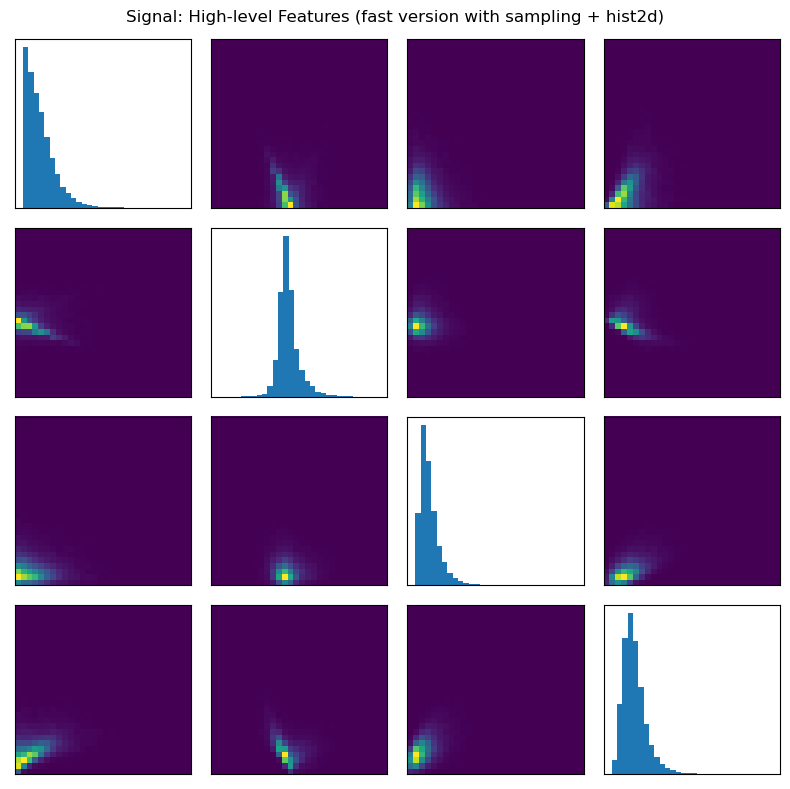

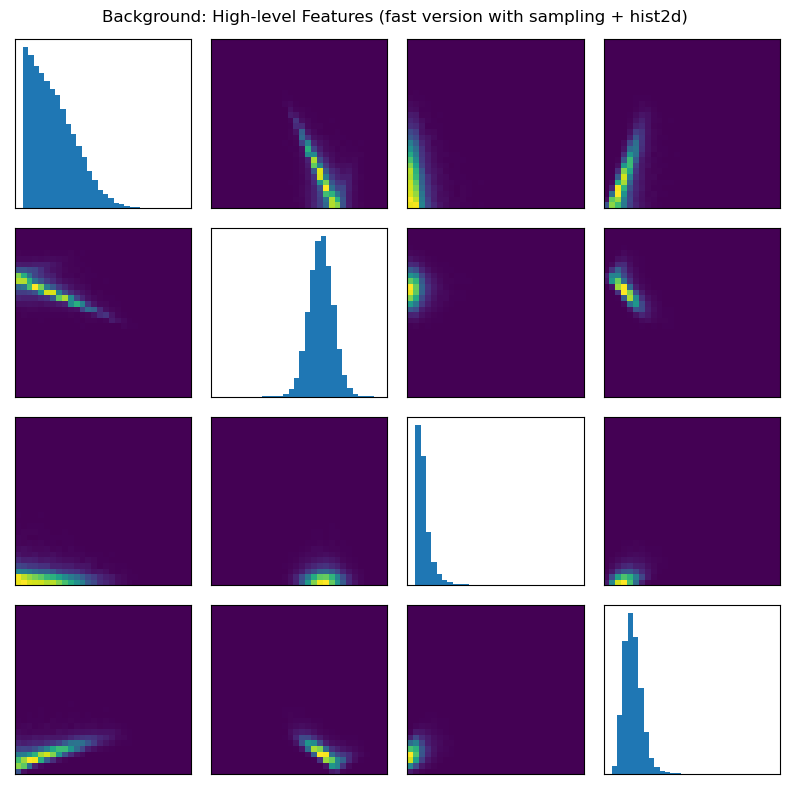

In [34]:
#Part b

def pair_plot_fast(data, variables, title):
    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(2*n, 2*n))
    
    # I randomly sampled the data to make it faster, at first I tried plotting everything, but it was very slow
    sample = data.sample(frac=0.1)  # used only 10%
    
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            
            if i == j:
                ax.hist(sample[variables[i]], bins=30, density=True)
            else:
                ax.hist2d(sample[variables[j]], sample[variables[i]], bins=30)

            
            ax.set_xticks([])
            ax.set_yticks([])
    
    fig.suptitle(title + " (fast version with sampling + hist2d)")
    plt.tight_layout()
    plt.show()
    
# Low-level features (reduced number to keep it readable)
low_vars = VarNames[1:5]

pair_plot_fast(df_sig, low_vars, "Signal: Low-level Features")
pair_plot_fast(df_bkg, low_vars, "Background: Low-level Features")


# High-level features
high_vars = VarNames[9:13]

pair_plot_fast(df_sig, high_vars, "Signal: High-level Features")
pair_plot_fast(df_bkg, high_vars, "Background: High-level Features")

Part b:To improve performance, I modified the pair plot function by sampling only 10% of the dataset instead of using all data points. Initially, plotting the full dataset was very slow. I also replaced scatter plots with 2D histograms (hist2d), which are more efficient because they group data into bins instead of plotting every individual point. These changes significantly reduced computation time while still preserving the overall patterns in the data.

Part c: At first, it was hard to tell which variables were useful just from individual histograms, but the pair plots made patterns more clear. I noticed that many low-level features overlap a lot between signal and background, which makes them harder to use for classification. On the other hand, several high-level features showed more separation in both histograms and scatter plots, so they seem more useful for differenciating between the two.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [10]:
#Part b

import numpy as np
# All observables
data_all = df[VarNames[1:]].values

# Compute covariance matrix
cov_matrix_all = np.cov(data_all, rowvar=False)

# Compute correlation matrix
corr_matrix_all = np.corrcoef(data_all, rowvar=False)

# Low-level features
low_data = df[VarNames[1:9]].values

cov_matrix_low = np.cov(low_data, rowvar=False)
corr_matrix_low = np.corrcoef(low_data, rowvar=False)

# High-level features
high_data = df[VarNames[9:17]].values

cov_matrix_high = np.cov(high_data, rowvar=False)
corr_matrix_high = np.corrcoef(high_data, rowvar=False)

In [67]:
#Part c

from tabulate import tabulate
from IPython.display import display, Markdown

# Function to display table nicely in notebook
def display_table(matrix, headers, title):
    # I rounded values because the raw output had too many decimals and it was hard to read
    rounded = np.round(matrix, 3)
    
    # Convert to tabulate format
    table = tabulate(rounded, headers=headers, showindex=headers, tablefmt="github")
    
    # Display as markdown so it looks like a clean table in the notebook
    display(Markdown(f"### {title}\n\n{table}"))

# All observables
headers_all = VarNames[1:]
display_table(cov_matrix_all, headers_all, "Covariance Matrix (All Observables)")
display_table(corr_matrix_all, headers_all, "Correlation Matrix (All Observables)")


# Low-level features
headers_low = VarNames[1:9]
display_table(cov_matrix_low, headers_low, "Covariance Matrix (Low-level Features)")
display_table(corr_matrix_low, headers_low, "Correlation Matrix (Low-level Features)")


# High-level features
headers_high = VarNames[9:17]
display_table(cov_matrix_high, headers_high, "Covariance Matrix (High-level Features)")
display_table(corr_matrix_high, headers_high, "Correlation Matrix (High-level Features)")

### Covariance Matrix (All Observables)

|              |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
|--------------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|------------|----------------|
| l_1_pT       |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |     0.098 |      -0.01  |  0.364 |    0.287 | -0.06  | -0.012 |  0.343 |       0.098 |     -0.047 |          0.022 |
| l_1_eta      |   -0     |     1.004 |    -0.001 |   -0     |     0.408 |    -0.001 | -0.002 |    -0.001 |    -0.001 |      -0.001 | -0.001 |   -0.001 |  0     |  0     | -0.001 |      -0.001 |     -0.001 |          0     |
| l_1_phi      |    0     |    -0.001 |     1.004 |    0.001 |     0     |    -0.267 |  0.001 |    -0.185 |     0.001 |      -0.002 |  0.001 |    0.001 |  0     |  0.001 |  0.001 |       0.001 |      0.001 |          0     |
| l_2_pT       |    0.305 |    -0     |     0.001 |    0.425 |    -0.001 |     0     |  0.079 |    -0.002 |    -0.001 |       0.051 |  0.325 |    0.163 | -0.099 | -0.069 |  0.322 |       0.006 |     -0.004 |         -0.028 |
| l_2_eta      |   -0     |     0.408 |     0     |   -0.001 |     1.006 |     0     |  0     |    -0     |     0.001 |      -0.001 | -0.001 |    0     |  0     |  0.001 | -0.001 |       0.001 |     -0     |          0     |
| l_2_phi      |    0.001 |    -0.001 |    -0.267 |    0     |     0     |     1.004 | -0     |    -0.035 |     0.001 |      -0.002 |  0.001 |    0.001 |  0.001 |  0.002 |  0.001 |       0.001 |     -0     |          0     |
| MET          |    0.228 |    -0.002 |     0.001 |    0.079 |     0     |    -0     |  0.762 |    -0.003 |     0.546 |       0.154 |  0.145 |    0.365 |  0.188 |  0.155 |  0.166 |       0.315 |      0.146 |          0.073 |
| MET_phi      |   -0.001 |    -0.001 |    -0.185 |   -0.002 |    -0     |    -0.035 | -0.003 |     1.003 |    -0.005 |      -0     | -0.001 |   -0.001 | -0     |  0     | -0.002 |      -0.001 |     -0.002 |          0     |
| MET_rel      |    0.098 |    -0.001 |     0.001 |   -0.001 |     0.001 |     0.001 |  0.546 |    -0.005 |     0.79  |      -0.12  |  0.044 |    0.302 |  0.249 |  0.409 |  0.082 |       0.415 |      0.146 |          0.055 |
| axial_MET    |   -0.01  |    -0.001 |    -0.002 |    0.051 |    -0.001 |    -0.002 |  0.154 |    -0     |    -0.12  |       1.005 |  0.017 |   -0.185 | -0.181 | -0.461 | -0.041 |      -0.233 |     -0.025 |         -0.054 |
| M_R          |    0.364 |    -0.001 |     0.001 |    0.325 |    -0.001 |     0.001 |  0.145 |    -0.001 |     0.044 |       0.017 |  0.392 |    0.21  | -0.113 | -0.037 |  0.38  |       0.074 |     -0.029 |         -0.014 |
| M_TR_2       |    0.287 |    -0.001 |     0.001 |    0.163 |     0     |     0.001 |  0.365 |    -0.001 |     0.302 |      -0.185 |  0.21  |    0.338 |  0.104 |  0.189 |  0.228 |       0.242 |      0.058 |          0.052 |
| R            |   -0.06  |     0     |     0     |   -0.099 |     0     |     0.001 |  0.188 |    -0     |     0.249 |      -0.181 | -0.113 |    0.104 |  0.222 |  0.232 | -0.083 |       0.165 |      0.087 |          0.058 |
| MT2          |   -0.012 |     0     |     0.001 |   -0.069 |     0.001 |     0.002 |  0.155 |     0     |     0.409 |      -0.461 | -0.037 |    0.189 |  0.232 |  0.738 | -0.011 |       0.433 |      0.021 |          0.045 |
| S_R          |    0.343 |    -0.001 |     0.001 |    0.322 |    -0.001 |     0.001 |  0.166 |    -0.002 |     0.082 |      -0.041 |  0.38  |    0.228 | -0.083 | -0.011 |  0.382 |       0.096 |     -0.003 |         -0.01  |
| M_Delta_R    |    0.098 |    -0.001 |     0.001 |    0.006 |     0.001 |     0.001 |  0.315 |    -0.001 |     0.415 |      -0.233 |  0.074 |    0.242 |  0.165 |  0.433 |  0.096 |       0.389 |      0.042 |          0.039 |
| dPhi_r_b     |   -0.047 |    -0.001 |     0.001 |   -0.004 |    -0     |    -0     |  0.146 |    -0.002 |     0.146 |      -0.025 | -0.029 |    0.058 |  0.087 |  0.021 | -0.003 |       0.042 |      0.19  |          0.009 |
| cos_theta_r1 |    0.022 |     0     |     0     |   -0.028 |     0     |     0     |  0.073 |     0     |     0.055 |      -0.054 | -0.014 |    0.052 |  0.058 |  0.045 | -0.01  |       0.039 |      0.009 |          0.039 |

### Correlation Matrix (All Observables)

|              |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
|--------------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|------------|----------------|
| l_1_pT       |    1     |    -0.001 |     0     |    0.684 |    -0.001 |     0.001 |  0.383 |    -0.001 |     0.16  |      -0.014 |  0.851 |    0.723 | -0.186 | -0.021 |  0.811 |       0.229 |     -0.157 |          0.165 |
| l_1_eta      |   -0.001 |     1     |    -0.001 |   -0     |     0.406 |    -0.001 | -0.002 |    -0.001 |    -0.002 |      -0.001 | -0.001 |   -0.001 |  0.001 |  0     | -0.001 |      -0.002 |     -0.002 |          0.002 |
| l_1_phi      |    0     |    -0.001 |     1     |    0.002 |     0     |    -0.266 |  0.001 |    -0.184 |     0.001 |      -0.002 |  0.002 |    0.001 |  0     |  0.001 |  0.002 |       0.001 |      0.002 |          0.001 |
| l_2_pT       |    0.684 |    -0     |     0.002 |    1     |    -0.001 |     0     |  0.14  |    -0.002 |    -0.001 |       0.078 |  0.797 |    0.43  | -0.324 | -0.123 |  0.799 |       0.014 |     -0.013 |         -0.217 |
| l_2_eta      |   -0.001 |     0.406 |     0     |   -0.001 |     1     |     0     |  0     |    -0     |     0.001 |      -0.001 | -0.001 |    0     |  0.001 |  0.002 | -0.001 |       0.001 |     -0.001 |          0.001 |
| l_2_phi      |    0.001 |    -0.001 |    -0.266 |    0     |     0     |     1     | -0     |    -0.035 |     0.002 |      -0.002 |  0.001 |    0.001 |  0.001 |  0.003 |  0.001 |       0.002 |     -0.001 |          0     |
| MET          |    0.383 |    -0.002 |     0.001 |    0.14  |     0     |    -0     |  1     |    -0.003 |     0.704 |       0.176 |  0.264 |    0.72  |  0.457 |  0.206 |  0.307 |       0.579 |      0.383 |          0.425 |
| MET_phi      |   -0.001 |    -0.001 |    -0.184 |   -0.002 |    -0     |    -0.035 | -0.003 |     1     |    -0.005 |      -0     | -0.002 |   -0.002 | -0     |  0     | -0.003 |      -0.001 |     -0.004 |          0.001 |
| MET_rel      |    0.16  |    -0.002 |     0.001 |   -0.001 |     0.001 |     0.002 |  0.704 |    -0.005 |     1     |      -0.134 |  0.078 |    0.584 |  0.595 |  0.535 |  0.15  |       0.748 |      0.378 |          0.316 |
| axial_MET    |   -0.014 |    -0.001 |    -0.002 |    0.078 |    -0.001 |    -0.002 |  0.176 |    -0     |    -0.134 |       1     |  0.027 |   -0.317 | -0.383 | -0.535 | -0.067 |      -0.373 |     -0.057 |         -0.272 |
| M_R          |    0.851 |    -0.001 |     0.002 |    0.797 |    -0.001 |     0.001 |  0.264 |    -0.002 |     0.078 |       0.027 |  1     |    0.577 | -0.383 | -0.068 |  0.981 |       0.189 |     -0.106 |         -0.116 |
| M_TR_2       |    0.723 |    -0.001 |     0.001 |    0.43  |     0     |     0.001 |  0.72  |    -0.002 |     0.584 |      -0.317 |  0.577 |    1     |  0.38  |  0.379 |  0.635 |       0.668 |      0.229 |          0.451 |
| R            |   -0.186 |     0.001 |     0     |   -0.324 |     0.001 |     0.001 |  0.457 |    -0     |     0.595 |      -0.383 | -0.383 |    0.38  |  1     |  0.574 | -0.287 |       0.564 |      0.424 |          0.627 |
| MT2          |   -0.021 |     0     |     0.001 |   -0.123 |     0.002 |     0.003 |  0.206 |     0     |     0.535 |      -0.535 | -0.068 |    0.379 |  0.574 |  1     | -0.021 |       0.809 |      0.056 |          0.264 |
| S_R          |    0.811 |    -0.001 |     0.002 |    0.799 |    -0.001 |     0.001 |  0.307 |    -0.003 |     0.15  |      -0.067 |  0.981 |    0.635 | -0.287 | -0.021 |  1     |       0.249 |     -0.013 |         -0.085 |
| M_Delta_R    |    0.229 |    -0.002 |     0.001 |    0.014 |     0.001 |     0.002 |  0.579 |    -0.001 |     0.748 |      -0.373 |  0.189 |    0.668 |  0.564 |  0.809 |  0.249 |       1     |      0.155 |          0.319 |
| dPhi_r_b     |   -0.157 |    -0.002 |     0.002 |   -0.013 |    -0.001 |    -0.001 |  0.383 |    -0.004 |     0.378 |      -0.057 | -0.106 |    0.229 |  0.424 |  0.056 | -0.013 |       0.155 |      1     |          0.106 |
| cos_theta_r1 |    0.165 |     0.002 |     0.001 |   -0.217 |     0.001 |     0     |  0.425 |     0.001 |     0.316 |      -0.272 | -0.116 |    0.451 |  0.627 |  0.264 | -0.085 |       0.319 |      0.106 |          1     |

### Covariance Matrix (Low-level Features)

|         |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
|---------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|
| l_1_pT  |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |
| l_1_eta |   -0     |     1.004 |    -0.001 |   -0     |     0.408 |    -0.001 | -0.002 |    -0.001 |
| l_1_phi |    0     |    -0.001 |     1.004 |    0.001 |     0     |    -0.267 |  0.001 |    -0.185 |
| l_2_pT  |    0.305 |    -0     |     0.001 |    0.425 |    -0.001 |     0     |  0.079 |    -0.002 |
| l_2_eta |   -0     |     0.408 |     0     |   -0.001 |     1.006 |     0     |  0     |    -0     |
| l_2_phi |    0.001 |    -0.001 |    -0.267 |    0     |     0     |     1.004 | -0     |    -0.035 |
| MET     |    0.228 |    -0.002 |     0.001 |    0.079 |     0     |    -0     |  0.762 |    -0.003 |
| MET_phi |   -0.001 |    -0.001 |    -0.185 |   -0.002 |    -0     |    -0.035 | -0.003 |     1.003 |

### Correlation Matrix (Low-level Features)

|         |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
|---------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|
| l_1_pT  |    1     |    -0.001 |     0     |    0.684 |    -0.001 |     0.001 |  0.383 |    -0.001 |
| l_1_eta |   -0.001 |     1     |    -0.001 |   -0     |     0.406 |    -0.001 | -0.002 |    -0.001 |
| l_1_phi |    0     |    -0.001 |     1     |    0.002 |     0     |    -0.266 |  0.001 |    -0.184 |
| l_2_pT  |    0.684 |    -0     |     0.002 |    1     |    -0.001 |     0     |  0.14  |    -0.002 |
| l_2_eta |   -0.001 |     0.406 |     0     |   -0.001 |     1     |     0     |  0     |    -0     |
| l_2_phi |    0.001 |    -0.001 |    -0.266 |    0     |     0     |     1     | -0     |    -0.035 |
| MET     |    0.383 |    -0.002 |     0.001 |    0.14  |     0     |    -0     |  1     |    -0.003 |
| MET_phi |   -0.001 |    -0.001 |    -0.184 |   -0.002 |    -0     |    -0.035 | -0.003 |     1     |

### Covariance Matrix (High-level Features)

|           |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |
|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|
| MET_rel   |     0.79  |      -0.12  |  0.044 |    0.302 |  0.249 |  0.409 |  0.082 |       0.415 |
| axial_MET |    -0.12  |       1.005 |  0.017 |   -0.185 | -0.181 | -0.461 | -0.041 |      -0.233 |
| M_R       |     0.044 |       0.017 |  0.392 |    0.21  | -0.113 | -0.037 |  0.38  |       0.074 |
| M_TR_2    |     0.302 |      -0.185 |  0.21  |    0.338 |  0.104 |  0.189 |  0.228 |       0.242 |
| R         |     0.249 |      -0.181 | -0.113 |    0.104 |  0.222 |  0.232 | -0.083 |       0.165 |
| MT2       |     0.409 |      -0.461 | -0.037 |    0.189 |  0.232 |  0.738 | -0.011 |       0.433 |
| S_R       |     0.082 |      -0.041 |  0.38  |    0.228 | -0.083 | -0.011 |  0.382 |       0.096 |
| M_Delta_R |     0.415 |      -0.233 |  0.074 |    0.242 |  0.165 |  0.433 |  0.096 |       0.389 |

### Correlation Matrix (High-level Features)

|           |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |
|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|
| MET_rel   |     1     |      -0.134 |  0.078 |    0.584 |  0.595 |  0.535 |  0.15  |       0.748 |
| axial_MET |    -0.134 |       1     |  0.027 |   -0.317 | -0.383 | -0.535 | -0.067 |      -0.373 |
| M_R       |     0.078 |       0.027 |  1     |    0.577 | -0.383 | -0.068 |  0.981 |       0.189 |
| M_TR_2    |     0.584 |      -0.317 |  0.577 |    1     |  0.38  |  0.379 |  0.635 |       0.668 |
| R         |     0.595 |      -0.383 | -0.383 |    0.38  |  1     |  0.574 | -0.287 |       0.564 |
| MT2       |     0.535 |      -0.535 | -0.068 |    0.379 |  0.574 |  1     | -0.021 |       0.809 |
| S_R       |     0.15  |      -0.067 |  0.981 |    0.635 | -0.287 | -0.021 |  1     |       0.249 |
| M_Delta_R |     0.748 |      -0.373 |  0.189 |    0.668 |  0.564 |  0.809 |  0.249 |       1     |

In [66]:
#Part d

def analyze_correlations(dataframe, variables, title):
    
    # Convert to numpy array because numpy functions require arrays
    data = dataframe[variables].values
    
    # Compute covariance and correlation matrices
    cov_matrix = np.cov(data, rowvar=False)
    corr_matrix = np.corrcoef(data, rowvar=False)
    
    # At first the numbers had too many decimals and were hard to read, so I rounded them
    cov_matrix = np.round(cov_matrix, 3)
    corr_matrix = np.round(corr_matrix, 3)
    
    # Convert to tabulate tables
    cov_table = tabulate(cov_matrix, headers=variables, showindex=variables, tablefmt="github")
    corr_table = tabulate(corr_matrix, headers=variables, showindex=variables, tablefmt="github")
    
    # Display nicely in notebook using Markdown
    display(Markdown(f"## {title}"))
    
    display(Markdown(f"### Covariance Matrix\n\n{cov_table}"))
    display(Markdown(f"### Correlation Matrix\n\n{corr_table}"))
    
# All observables
analyze_correlations(df, VarNames[1:], "All Observables")

# Low-level features
analyze_correlations(df, VarNames[1:9], "Low-level Features")

# High-level features
analyze_correlations(df, VarNames[9:17], "High-level Features")

## All Observables

### Covariance Matrix

|              |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
|--------------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|------------|----------------|
| l_1_pT       |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |     0.098 |      -0.01  |  0.364 |    0.287 | -0.06  | -0.012 |  0.343 |       0.098 |     -0.047 |          0.022 |
| l_1_eta      |   -0     |     1.004 |    -0.001 |   -0     |     0.408 |    -0.001 | -0.002 |    -0.001 |    -0.001 |      -0.001 | -0.001 |   -0.001 |  0     |  0     | -0.001 |      -0.001 |     -0.001 |          0     |
| l_1_phi      |    0     |    -0.001 |     1.004 |    0.001 |     0     |    -0.267 |  0.001 |    -0.185 |     0.001 |      -0.002 |  0.001 |    0.001 |  0     |  0.001 |  0.001 |       0.001 |      0.001 |          0     |
| l_2_pT       |    0.305 |    -0     |     0.001 |    0.425 |    -0.001 |     0     |  0.079 |    -0.002 |    -0.001 |       0.051 |  0.325 |    0.163 | -0.099 | -0.069 |  0.322 |       0.006 |     -0.004 |         -0.028 |
| l_2_eta      |   -0     |     0.408 |     0     |   -0.001 |     1.006 |     0     |  0     |    -0     |     0.001 |      -0.001 | -0.001 |    0     |  0     |  0.001 | -0.001 |       0.001 |     -0     |          0     |
| l_2_phi      |    0.001 |    -0.001 |    -0.267 |    0     |     0     |     1.004 | -0     |    -0.035 |     0.001 |      -0.002 |  0.001 |    0.001 |  0.001 |  0.002 |  0.001 |       0.001 |     -0     |          0     |
| MET          |    0.228 |    -0.002 |     0.001 |    0.079 |     0     |    -0     |  0.762 |    -0.003 |     0.546 |       0.154 |  0.145 |    0.365 |  0.188 |  0.155 |  0.166 |       0.315 |      0.146 |          0.073 |
| MET_phi      |   -0.001 |    -0.001 |    -0.185 |   -0.002 |    -0     |    -0.035 | -0.003 |     1.003 |    -0.005 |      -0     | -0.001 |   -0.001 | -0     |  0     | -0.002 |      -0.001 |     -0.002 |          0     |
| MET_rel      |    0.098 |    -0.001 |     0.001 |   -0.001 |     0.001 |     0.001 |  0.546 |    -0.005 |     0.79  |      -0.12  |  0.044 |    0.302 |  0.249 |  0.409 |  0.082 |       0.415 |      0.146 |          0.055 |
| axial_MET    |   -0.01  |    -0.001 |    -0.002 |    0.051 |    -0.001 |    -0.002 |  0.154 |    -0     |    -0.12  |       1.005 |  0.017 |   -0.185 | -0.181 | -0.461 | -0.041 |      -0.233 |     -0.025 |         -0.054 |
| M_R          |    0.364 |    -0.001 |     0.001 |    0.325 |    -0.001 |     0.001 |  0.145 |    -0.001 |     0.044 |       0.017 |  0.392 |    0.21  | -0.113 | -0.037 |  0.38  |       0.074 |     -0.029 |         -0.014 |
| M_TR_2       |    0.287 |    -0.001 |     0.001 |    0.163 |     0     |     0.001 |  0.365 |    -0.001 |     0.302 |      -0.185 |  0.21  |    0.338 |  0.104 |  0.189 |  0.228 |       0.242 |      0.058 |          0.052 |
| R            |   -0.06  |     0     |     0     |   -0.099 |     0     |     0.001 |  0.188 |    -0     |     0.249 |      -0.181 | -0.113 |    0.104 |  0.222 |  0.232 | -0.083 |       0.165 |      0.087 |          0.058 |
| MT2          |   -0.012 |     0     |     0.001 |   -0.069 |     0.001 |     0.002 |  0.155 |     0     |     0.409 |      -0.461 | -0.037 |    0.189 |  0.232 |  0.738 | -0.011 |       0.433 |      0.021 |          0.045 |
| S_R          |    0.343 |    -0.001 |     0.001 |    0.322 |    -0.001 |     0.001 |  0.166 |    -0.002 |     0.082 |      -0.041 |  0.38  |    0.228 | -0.083 | -0.011 |  0.382 |       0.096 |     -0.003 |         -0.01  |
| M_Delta_R    |    0.098 |    -0.001 |     0.001 |    0.006 |     0.001 |     0.001 |  0.315 |    -0.001 |     0.415 |      -0.233 |  0.074 |    0.242 |  0.165 |  0.433 |  0.096 |       0.389 |      0.042 |          0.039 |
| dPhi_r_b     |   -0.047 |    -0.001 |     0.001 |   -0.004 |    -0     |    -0     |  0.146 |    -0.002 |     0.146 |      -0.025 | -0.029 |    0.058 |  0.087 |  0.021 | -0.003 |       0.042 |      0.19  |          0.009 |
| cos_theta_r1 |    0.022 |     0     |     0     |   -0.028 |     0     |     0     |  0.073 |     0     |     0.055 |      -0.054 | -0.014 |    0.052 |  0.058 |  0.045 | -0.01  |       0.039 |      0.009 |          0.039 |

### Correlation Matrix

|              |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |   dPhi_r_b |   cos_theta_r1 |
|--------------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|------------|----------------|
| l_1_pT       |    1     |    -0.001 |     0     |    0.684 |    -0.001 |     0.001 |  0.383 |    -0.001 |     0.16  |      -0.014 |  0.851 |    0.723 | -0.186 | -0.021 |  0.811 |       0.229 |     -0.157 |          0.165 |
| l_1_eta      |   -0.001 |     1     |    -0.001 |   -0     |     0.406 |    -0.001 | -0.002 |    -0.001 |    -0.002 |      -0.001 | -0.001 |   -0.001 |  0.001 |  0     | -0.001 |      -0.002 |     -0.002 |          0.002 |
| l_1_phi      |    0     |    -0.001 |     1     |    0.002 |     0     |    -0.266 |  0.001 |    -0.184 |     0.001 |      -0.002 |  0.002 |    0.001 |  0     |  0.001 |  0.002 |       0.001 |      0.002 |          0.001 |
| l_2_pT       |    0.684 |    -0     |     0.002 |    1     |    -0.001 |     0     |  0.14  |    -0.002 |    -0.001 |       0.078 |  0.797 |    0.43  | -0.324 | -0.123 |  0.799 |       0.014 |     -0.013 |         -0.217 |
| l_2_eta      |   -0.001 |     0.406 |     0     |   -0.001 |     1     |     0     |  0     |    -0     |     0.001 |      -0.001 | -0.001 |    0     |  0.001 |  0.002 | -0.001 |       0.001 |     -0.001 |          0.001 |
| l_2_phi      |    0.001 |    -0.001 |    -0.266 |    0     |     0     |     1     | -0     |    -0.035 |     0.002 |      -0.002 |  0.001 |    0.001 |  0.001 |  0.003 |  0.001 |       0.002 |     -0.001 |          0     |
| MET          |    0.383 |    -0.002 |     0.001 |    0.14  |     0     |    -0     |  1     |    -0.003 |     0.704 |       0.176 |  0.264 |    0.72  |  0.457 |  0.206 |  0.307 |       0.579 |      0.383 |          0.425 |
| MET_phi      |   -0.001 |    -0.001 |    -0.184 |   -0.002 |    -0     |    -0.035 | -0.003 |     1     |    -0.005 |      -0     | -0.002 |   -0.002 | -0     |  0     | -0.003 |      -0.001 |     -0.004 |          0.001 |
| MET_rel      |    0.16  |    -0.002 |     0.001 |   -0.001 |     0.001 |     0.002 |  0.704 |    -0.005 |     1     |      -0.134 |  0.078 |    0.584 |  0.595 |  0.535 |  0.15  |       0.748 |      0.378 |          0.316 |
| axial_MET    |   -0.014 |    -0.001 |    -0.002 |    0.078 |    -0.001 |    -0.002 |  0.176 |    -0     |    -0.134 |       1     |  0.027 |   -0.317 | -0.383 | -0.535 | -0.067 |      -0.373 |     -0.057 |         -0.272 |
| M_R          |    0.851 |    -0.001 |     0.002 |    0.797 |    -0.001 |     0.001 |  0.264 |    -0.002 |     0.078 |       0.027 |  1     |    0.577 | -0.383 | -0.068 |  0.981 |       0.189 |     -0.106 |         -0.116 |
| M_TR_2       |    0.723 |    -0.001 |     0.001 |    0.43  |     0     |     0.001 |  0.72  |    -0.002 |     0.584 |      -0.317 |  0.577 |    1     |  0.38  |  0.379 |  0.635 |       0.668 |      0.229 |          0.451 |
| R            |   -0.186 |     0.001 |     0     |   -0.324 |     0.001 |     0.001 |  0.457 |    -0     |     0.595 |      -0.383 | -0.383 |    0.38  |  1     |  0.574 | -0.287 |       0.564 |      0.424 |          0.627 |
| MT2          |   -0.021 |     0     |     0.001 |   -0.123 |     0.002 |     0.003 |  0.206 |     0     |     0.535 |      -0.535 | -0.068 |    0.379 |  0.574 |  1     | -0.021 |       0.809 |      0.056 |          0.264 |
| S_R          |    0.811 |    -0.001 |     0.002 |    0.799 |    -0.001 |     0.001 |  0.307 |    -0.003 |     0.15  |      -0.067 |  0.981 |    0.635 | -0.287 | -0.021 |  1     |       0.249 |     -0.013 |         -0.085 |
| M_Delta_R    |    0.229 |    -0.002 |     0.001 |    0.014 |     0.001 |     0.002 |  0.579 |    -0.001 |     0.748 |      -0.373 |  0.189 |    0.668 |  0.564 |  0.809 |  0.249 |       1     |      0.155 |          0.319 |
| dPhi_r_b     |   -0.157 |    -0.002 |     0.002 |   -0.013 |    -0.001 |    -0.001 |  0.383 |    -0.004 |     0.378 |      -0.057 | -0.106 |    0.229 |  0.424 |  0.056 | -0.013 |       0.155 |      1     |          0.106 |
| cos_theta_r1 |    0.165 |     0.002 |     0.001 |   -0.217 |     0.001 |     0     |  0.425 |     0.001 |     0.316 |      -0.272 | -0.116 |    0.451 |  0.627 |  0.264 | -0.085 |       0.319 |      0.106 |          1     |

## Low-level Features

### Covariance Matrix

|         |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
|---------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|
| l_1_pT  |    0.467 |    -0     |     0     |    0.305 |    -0     |     0.001 |  0.228 |    -0.001 |
| l_1_eta |   -0     |     1.004 |    -0.001 |   -0     |     0.408 |    -0.001 | -0.002 |    -0.001 |
| l_1_phi |    0     |    -0.001 |     1.004 |    0.001 |     0     |    -0.267 |  0.001 |    -0.185 |
| l_2_pT  |    0.305 |    -0     |     0.001 |    0.425 |    -0.001 |     0     |  0.079 |    -0.002 |
| l_2_eta |   -0     |     0.408 |     0     |   -0.001 |     1.006 |     0     |  0     |    -0     |
| l_2_phi |    0.001 |    -0.001 |    -0.267 |    0     |     0     |     1.004 | -0     |    -0.035 |
| MET     |    0.228 |    -0.002 |     0.001 |    0.079 |     0     |    -0     |  0.762 |    -0.003 |
| MET_phi |   -0.001 |    -0.001 |    -0.185 |   -0.002 |    -0     |    -0.035 | -0.003 |     1.003 |

### Correlation Matrix

|         |   l_1_pT |   l_1_eta |   l_1_phi |   l_2_pT |   l_2_eta |   l_2_phi |    MET |   MET_phi |
|---------|----------|-----------|-----------|----------|-----------|-----------|--------|-----------|
| l_1_pT  |    1     |    -0.001 |     0     |    0.684 |    -0.001 |     0.001 |  0.383 |    -0.001 |
| l_1_eta |   -0.001 |     1     |    -0.001 |   -0     |     0.406 |    -0.001 | -0.002 |    -0.001 |
| l_1_phi |    0     |    -0.001 |     1     |    0.002 |     0     |    -0.266 |  0.001 |    -0.184 |
| l_2_pT  |    0.684 |    -0     |     0.002 |    1     |    -0.001 |     0     |  0.14  |    -0.002 |
| l_2_eta |   -0.001 |     0.406 |     0     |   -0.001 |     1     |     0     |  0     |    -0     |
| l_2_phi |    0.001 |    -0.001 |    -0.266 |    0     |     0     |     1     | -0     |    -0.035 |
| MET     |    0.383 |    -0.002 |     0.001 |    0.14  |     0     |    -0     |  1     |    -0.003 |
| MET_phi |   -0.001 |    -0.001 |    -0.184 |   -0.002 |    -0     |    -0.035 | -0.003 |     1     |

## High-level Features

### Covariance Matrix

|           |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |
|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|
| MET_rel   |     0.79  |      -0.12  |  0.044 |    0.302 |  0.249 |  0.409 |  0.082 |       0.415 |
| axial_MET |    -0.12  |       1.005 |  0.017 |   -0.185 | -0.181 | -0.461 | -0.041 |      -0.233 |
| M_R       |     0.044 |       0.017 |  0.392 |    0.21  | -0.113 | -0.037 |  0.38  |       0.074 |
| M_TR_2    |     0.302 |      -0.185 |  0.21  |    0.338 |  0.104 |  0.189 |  0.228 |       0.242 |
| R         |     0.249 |      -0.181 | -0.113 |    0.104 |  0.222 |  0.232 | -0.083 |       0.165 |
| MT2       |     0.409 |      -0.461 | -0.037 |    0.189 |  0.232 |  0.738 | -0.011 |       0.433 |
| S_R       |     0.082 |      -0.041 |  0.38  |    0.228 | -0.083 | -0.011 |  0.382 |       0.096 |
| M_Delta_R |     0.415 |      -0.233 |  0.074 |    0.242 |  0.165 |  0.433 |  0.096 |       0.389 |

### Correlation Matrix

|           |   MET_rel |   axial_MET |    M_R |   M_TR_2 |      R |    MT2 |    S_R |   M_Delta_R |
|-----------|-----------|-------------|--------|----------|--------|--------|--------|-------------|
| MET_rel   |     1     |      -0.134 |  0.078 |    0.584 |  0.595 |  0.535 |  0.15  |       0.748 |
| axial_MET |    -0.134 |       1     |  0.027 |   -0.317 | -0.383 | -0.535 | -0.067 |      -0.373 |
| M_R       |     0.078 |       0.027 |  1     |    0.577 | -0.383 | -0.068 |  0.981 |       0.189 |
| M_TR_2    |     0.584 |      -0.317 |  0.577 |    1     |  0.38  |  0.379 |  0.635 |       0.668 |
| R         |     0.595 |      -0.383 | -0.383 |    0.38  |  1     |  0.574 | -0.287 |       0.564 |
| MT2       |     0.535 |      -0.535 | -0.068 |    0.379 |  0.574 |  1     | -0.021 |       0.809 |
| S_R       |     0.15  |      -0.067 |  0.981 |    0.635 | -0.287 | -0.021 |  1     |       0.249 |
| M_Delta_R |     0.748 |      -0.373 |  0.189 |    0.668 |  0.564 |  0.809 |  0.249 |       1     |

Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

Exercise 5.1: The optimal selection depends on how the two distributions differ for each observable. If the signal distribution is shifted toward higher values than the background, the condition x > xc is most effective. If the signal is concentrated at lower values, then x < xc is preferred. In cases where the signal is clustered around a central value while the background is more spread out, a condition like |x-μ|< xc can be used. Conversely, if the background is concentrated near a mean and the signal lies farther away, then |x-μ| > xc is more appropriate.

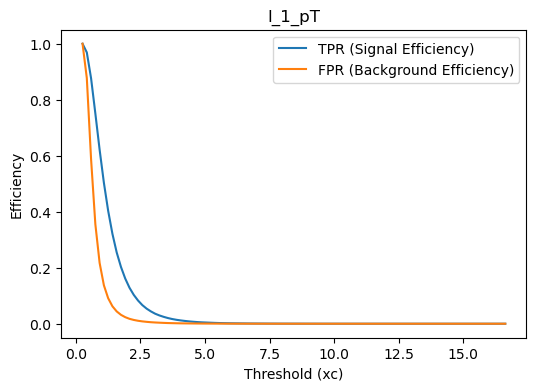

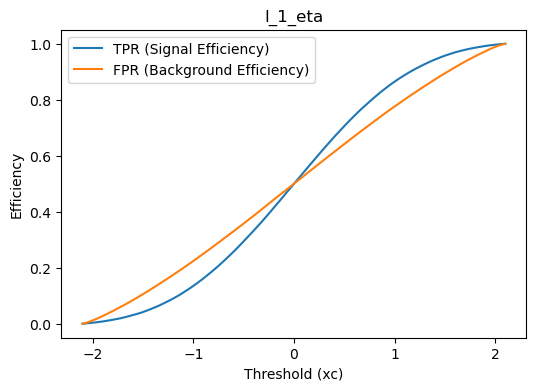

In [18]:
# Excercise 5.2

def compute_efficiencies(signal, background, mode="greater"):
    
    # I used linspace to scan possible threshold values
    xc_values = np.linspace(min(signal.min(), background.min()), max(signal.max(), background.max()), 100)
    
    tpr = []
    fpr = []
    
    for xc in xc_values:
        if mode == "greater":
            tpr.append(np.sum(signal > xc) / len(signal))
            fpr.append(np.sum(background > xc) / len(background))
        
        elif mode == "less":
            tpr.append(np.sum(signal < xc) / len(signal))
            fpr.append(np.sum(background < xc) / len(background))
    
    return xc_values, np.array(tpr), np.array(fpr)


def plot_efficiencies(df_sig, df_bkg, variable, mode="greater"):
    signal = df_sig[variable].values
    background = df_bkg[variable].values
    
    xc, tpr, fpr = compute_efficiencies(signal, background, mode)
    
    plt.figure(figsize=(6,4))
    
    # I plotted both curves together so I can compare them easily
    plt.plot(xc, tpr, label="TPR (Signal Efficiency)")
    plt.plot(xc, fpr, label="FPR (Background Efficiency)")
    
    plt.xlabel("Threshold (xc)")
    plt.ylabel("Efficiency")
    plt.title(variable)
    plt.legend()
    
    plt.show()

plot_efficiencies(df_sig, df_bkg, VarNames[1], mode="greater")
plot_efficiencies(df_sig, df_bkg, VarNames[2], mode="less")

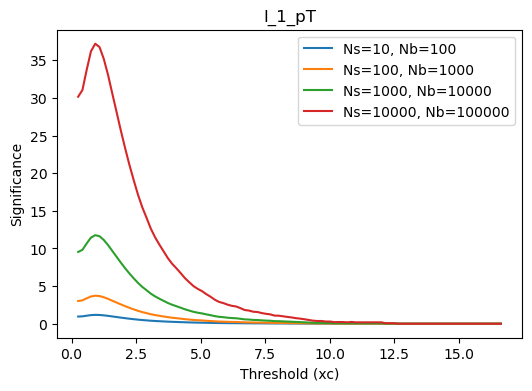

In [60]:
# Excerise 5.3

def compute_significance(signal, background, Ns, Nb, mode="greater"):
    xc_values = np.linspace(min(signal.min(), background.min()),
                            max(signal.max(), background.max()), 100)
    
    significance = []
    
    for xc in xc_values:
        if mode == "greater":
            eps_s = np.sum(signal > xc) / len(signal)
            eps_b = np.sum(background > xc) / len(background)
        
        elif mode == "less":
            eps_s = np.sum(signal < xc) / len(signal)
            eps_b = np.sum(background < xc) / len(background)
        
        # Expected number after selection
        Ns_prime = eps_s * Ns
        Nb_prime = eps_b * Nb
        
        # I used a check to avoid division by zero
        if Ns_prime + Nb_prime > 0:
            sig = Ns_prime / np.sqrt(Ns_prime + Nb_prime)
        else:
            sig = 0
        
        significance.append(sig)
    
    return xc_values, np.array(significance)


def plot_significance(df_sig, df_bkg, variable, mode="greater"):
    signal = df_sig[variable].values
    background = df_bkg[variable].values
    
    # Given scenarios
    scenarios = [(10, 100),(100, 1000),(1000, 10000),(10000, 100000)]
    
    plt.figure(figsize=(6,4))
    
    for Ns, Nb in scenarios:
        xc, sig = compute_significance(signal, background, Ns, Nb, mode)
        
        # I plotted all scenarios on the same graph for comparison
        plt.plot(xc, sig, label=f"Ns={Ns}, Nb={Nb}")
    
    plt.xlabel("Threshold (xc)")
    plt.ylabel("Significance")
    plt.title(variable)
    plt.legend()
    
    plt.show()

plot_significance(df_sig, df_bkg, VarNames[1], mode="greater")

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




Excerise 6.1: I chose variables where the significance peaked clearly and where the signal efficiency remained relatively high while background efficiency decreased.
   - VarNames[1] with condition x > xc
   - VarNames[2] with condition x < xc
   - VarNames[9] with condition x > xc

In [64]:
# Excerise 6.2

def apply_cut(data, variable, xc, mode):
    if mode == "greater":
        return data[data[variable] > xc]
    elif mode == "less":
        return data[data[variable] < xc]


def cut_flow(df_sig, df_bkg, cuts, Ns, Nb, title):
    # Start with full datasets
    sig_current = df_sig.copy()
    bkg_current = df_bkg.copy()
    
    rows = []
    
    for i, (var, xc, mode) in enumerate(cuts):
        
        # Apply cuts step by step
        sig_current = apply_cut(sig_current, var, xc, mode)
        bkg_current = apply_cut(bkg_current, var, xc, mode)
        
        # Compute efficiencies
        eps_s = len(sig_current) / len(df_sig)
        eps_b = len(bkg_current) / len(df_bkg)
        
        # Compute expected counts
        Ns_prime = eps_s * Ns
        Nb_prime = eps_b * Nb
        
        # Compute significance
        if Ns_prime + Nb_prime > 0:
            significance = Ns_prime / np.sqrt(Ns_prime + Nb_prime)
        else:
            significance = 0
        
        # Store results
        rows.append([
            f"Cut {i+1}: {var}",
            round(eps_s, 3),
            round(eps_b, 3),
            round(Ns_prime, 2),
            round(Nb_prime, 2),
            round(significance, 3)])
    
    headers = ["Cut", "εS", "εB", "N'S", "N'B", "σS'"]
    
    table = tabulate(rows, headers=headers, tablefmt="github")
    
    display(Markdown(f"### {title}\n\n{table}"))

In [44]:
#Excerise 6.2

cuts = [(VarNames[1], 0.5, "greater"),
    (VarNames[2], -0.3, "less"),
    (VarNames[9], 1.0, "greater")]

cut_flow(df_sig, df_bkg, cuts, 10, 100, "Scenario 1: Ns=10, Nb=100")
cut_flow(df_sig, df_bkg, cuts, 100, 1000, "Scenario 2: Ns=100, Nb=1000")
cut_flow(df_sig, df_bkg, cuts, 1000, 10000, "Scenario 3: Ns=1000, Nb=10000")
cut_flow(df_sig, df_bkg, cuts, 10000, 100000, "Scenario 4: Ns=10000, Nb=100000")

### Scenario 1: Ns=10, Nb=100

| Cut            |    εS |    εB |   N'S |   N'B |   σS' |
|----------------|-------|-------|-------|-------|-------|
| Cut 1: l_1_pT  | 0.931 | 0.741 |  9.31 | 74.08 | 1.019 |
| Cut 2: l_1_eta | 0.346 | 0.307 |  3.46 | 30.68 | 0.592 |
| Cut 3: MET_rel | 0.176 | 0.095 |  1.76 |  9.5  | 0.525 |

### Scenario 2: Ns=100, Nb=1000

| Cut            |    εS |    εB |   N'S |    N'B |   σS' |
|----------------|-------|-------|-------|--------|-------|
| Cut 1: l_1_pT  | 0.931 | 0.741 | 93.09 | 740.84 | 3.224 |
| Cut 2: l_1_eta | 0.346 | 0.307 | 34.58 | 306.83 | 1.871 |
| Cut 3: MET_rel | 0.176 | 0.095 | 17.61 |  95.02 | 1.659 |

### Scenario 3: Ns=1000, Nb=10000

| Cut            |    εS |    εB |    N'S |     N'B |    σS' |
|----------------|-------|-------|--------|---------|--------|
| Cut 1: l_1_pT  | 0.931 | 0.741 | 930.89 | 7408.43 | 10.194 |
| Cut 2: l_1_eta | 0.346 | 0.307 | 345.76 | 3068.27 |  5.918 |
| Cut 3: MET_rel | 0.176 | 0.095 | 176.1  |  950.16 |  5.247 |

### Scenario 4: Ns=10000, Nb=100000

| Cut            |    εS |    εB |     N'S |      N'B |    σS' |
|----------------|-------|-------|---------|----------|--------|
| Cut 1: l_1_pT  | 0.931 | 0.741 | 9308.86 | 74084.3  | 32.235 |
| Cut 2: l_1_eta | 0.346 | 0.307 | 3457.61 | 30682.7  | 18.713 |
| Cut 3: MET_rel | 0.176 | 0.095 | 1761    |  9501.58 | 16.594 |

In [61]:
#Excerise 6.3

def apply_cut(data, variable, xc, mode):
    if mode == "greater":
        return data[data[variable] > xc]
    elif mode == "less":
        return data[data[variable] < xc]


def compute_significance_curve(signal, background, Ns, Nb, mode="greater"):
    xc_vals = np.linspace(min(signal.min(), background.min()), max(signal.max(), background.max()), 100)
    
    sig_vals = []
    
    for xc in xc_vals:
        if mode == "greater":
            eps_s = np.sum(signal > xc) / len(signal)
            eps_b = np.sum(background > xc) / len(background)
        else:
            eps_s = np.sum(signal < xc) / len(signal)
            eps_b = np.sum(background < xc) / len(background)
        
        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb
        
        if Ns_p + Nb_p > 0:
            sig = Ns_p / np.sqrt(Ns_p + Nb_p)
        else:
            sig = 0
        
        sig_vals.append(sig)
    
    return xc_vals, np.array(sig_vals)


def test_order(df_sig, df_bkg, var1, xc1, mode1, var2, mode2, Ns, Nb):
    
    # Apply first cut
    sig_cut1 = apply_cut(df_sig, var1, xc1, mode1)
    bkg_cut1 = apply_cut(df_bkg, var1, xc1, mode1)
    
    # Now optimize second variable after first cut
    signal2 = sig_cut1[var2].values
    background2 = bkg_cut1[var2].values
    
    xc2_vals, sig_after = compute_significance_curve(signal2, background2, Ns, Nb, mode2)
    
    # Reverse order
    sig_after_rev = []
    
    for xc2 in xc2_vals:
        sig_cut2 = apply_cut(df_sig, var2, xc2, mode2)
        bkg_cut2 = apply_cut(df_bkg, var2, xc2, mode2)
        
        signal1 = sig_cut2[var1].values
        background1 = bkg_cut2[var1].values
        
        # Compute significance for fixed xc1 AFTER second cut
        if mode1 == "greater":
            eps_s = np.sum(signal1 > xc1) / len(signal1) if len(signal1) > 0 else 0
            eps_b = np.sum(background1 > xc1) / len(background1) if len(background1) > 0 else 0
        else:
            eps_s = np.sum(signal1 < xc1) / len(signal1) if len(signal1) > 0 else 0
            eps_b = np.sum(background1 < xc1) / len(background1) if len(background1) > 0 else 0
        
        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb
        
        if Ns_p + Nb_p > 0:
            sig_val = Ns_p / np.sqrt(Ns_p + Nb_p)
        else:
            sig_val = 0
        
        sig_after_rev.append(sig_val)
    
    
    plt.figure(figsize=(6,4))
    
    # I plotted both cases together to clearly see the difference
    plt.plot(xc2_vals, sig_after, label="first var1")
    plt.plot(xc2_vals, sig_after_rev, linestyle="dashed", label="first var2")
    
    plt.xlabel(f"Threshold for {var2}")
    plt.ylabel("Significance")
    plt.title("Effect of Cut Order on Significance")
    plt.legend()
    
    plt.show()

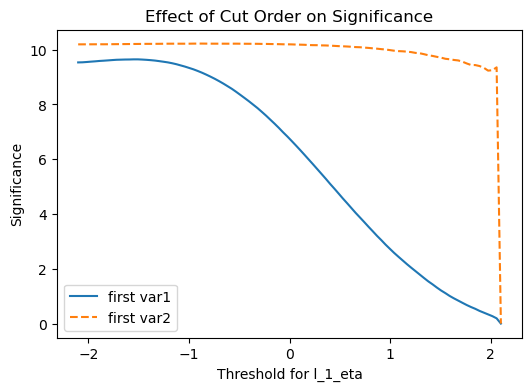

In [27]:
#Exercise 6.3

var1 = VarNames[1]
var2 = VarNames[2]

# Example threshold (use your optimal xc from 5.3)
xc1 = 0.5

# Run test
test_order(df_sig, df_bkg, var1, xc1, "greater", var2, "greater", Ns=1000, Nb=10000)

I applied a selection on one observable first and then recomputed the optimal threshold for a second observable using the filtered dataset. This improved the overall significance compared to using the original thresholds. Testing the reversing of the order of selections, I found that the final significance changed depending on the order, proving that correlations between variables impact the optimization process.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



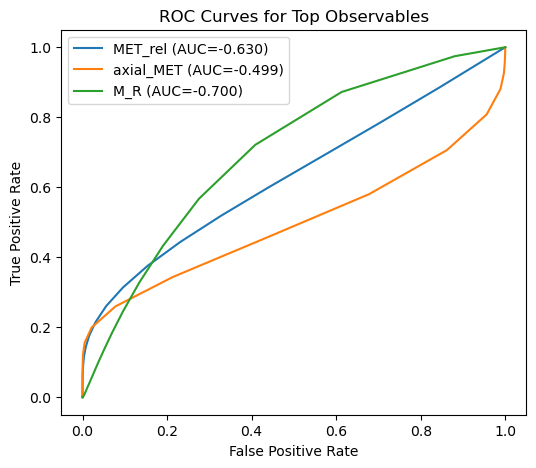

In [28]:
# Excerise 7.1

def compute_roc(signal, background, mode="greater"):
    
    # I scan across thresholds just like in previous exercises
    xc_vals = np.linspace(min(signal.min(), background.min()),
                          max(signal.max(), background.max()), 100)
    
    tpr = []
    fpr = []
    
    for xc in xc_vals:
        if mode == "greater":
            tpr.append(np.sum(signal > xc) / len(signal))
            fpr.append(np.sum(background > xc) / len(background))
        else:
            tpr.append(np.sum(signal < xc) / len(signal))
            fpr.append(np.sum(background < xc) / len(background))
    
    return np.array(fpr), np.array(tpr)


def compute_auc(fpr, tpr):
    # I used trapezoidal rule because it's simple and works well
    return np.trapz(tpr, fpr)


vars_top = [VarNames[9], VarNames[10], VarNames[11]]

plt.figure(figsize=(6,5))

for var in vars_top:
    signal = df_sig[var].values
    background = df_bkg[var].values
    
    fpr, tpr = compute_roc(signal, background, mode="greater")
    auc = compute_auc(fpr, tpr)
    
    # I added AUC to the legend since that's what the question asks
    plt.plot(fpr, tpr, label=f"{var} (AUC={auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Top Observables")
plt.legend()

plt.show()

In [41]:
# Excerise 7.2

def plot_roc(df_sig, df_bkg, variables, modes):
    
    plt.figure(figsize=(6,5))
    
    for var, mode in zip(variables, modes):
        
        signal = df_sig[var].values
        background = df_bkg[var].values
        
        fpr, tpr = compute_roc(signal, background, mode)
        auc = compute_auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{var}")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend()
    
    plt.show()

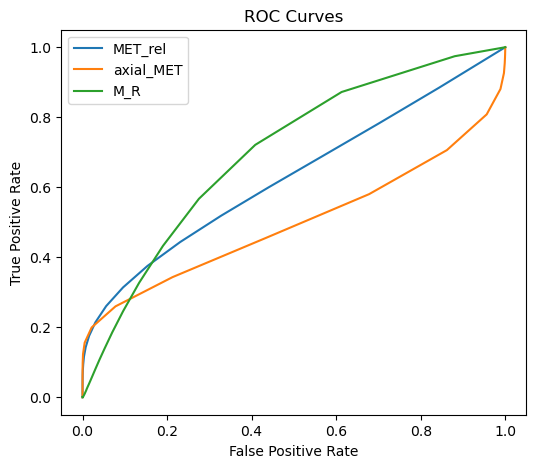

In [42]:
# Excerise 7.2

# At first I wasn't sure which ones to use, so I picked high-level features
variables = [VarNames[9], VarNames[10], VarNames[11]]

# Most of these worked better with x > xc based on earlier plots
modes = ["greater", "greater", "greater"]

plot_roc(df_sig, df_bkg, variables, modes)

In [47]:
# Excerise 7.3

def apply_cut(data, variable, xc, mode):
    if mode == "greater":
        return data[data[variable] > xc]
    elif mode == "less":
        return data[data[variable] < xc]


def roc_after_each_cut(df_sig, df_bkg, cuts, var_to_plot, mode="greater"):
    
    plt.figure(figsize=(6,5))
    
    sig_current = df_sig.copy()
    bkg_current = df_bkg.copy()
    
    # Initial ROC (before cuts)
    fpr, tpr = compute_roc(sig_current[var_to_plot], bkg_current[var_to_plot], mode)
    plt.plot(fpr, tpr, label="No cuts")
    
    # Apply cuts one by one
    for i, (var, xc, m) in enumerate(cuts):
        
        sig_current = apply_cut(sig_current, var, xc, m)
        bkg_current = apply_cut(bkg_current, var, xc, m)
        
        fpr, tpr = compute_roc(sig_current[var_to_plot], bkg_current[var_to_plot], mode)
        plt.plot(fpr, tpr, label=f"After cut {i+1}")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC After Successive Cuts")
    plt.legend()
    
    plt.show()

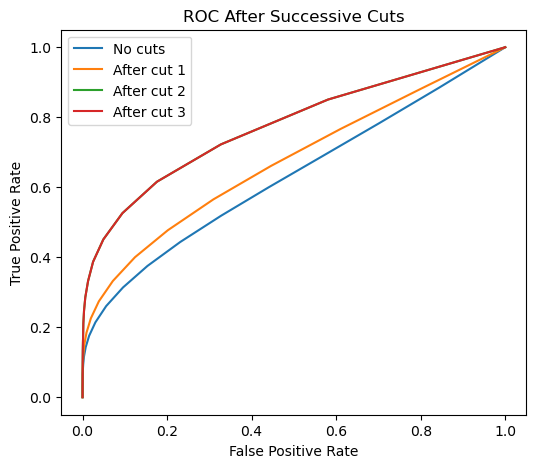

In [48]:
# Excerise 7.3

# I chose a mix of strong variables
cuts = [(VarNames[9], 0.5, "greater"),(VarNames[10], 0.3, "greater"),(VarNames[1], 0.0, "greater")]

# I chose one variable to track how the ROC changes after cuts
var_to_plot = VarNames[9]

roc_after_each_cut(df_sig, df_bkg, cuts, var_to_plot, mode="greater")

In [49]:
# Excerise 7.4

def compare_cut_order(df_sig, df_bkg, cuts1, cuts2, var_to_plot, mode="greater"):
    
    plt.figure(figsize=(6,5))
    
    # First order
    sig1 = df_sig.copy()
    bkg1 = df_bkg.copy()
    
    for var, xc, m in cuts1:
        sig1 = apply_cut(sig1, var, xc, m)
        bkg1 = apply_cut(bkg1, var, xc, m)
    
    fpr1, tpr1 = compute_roc(sig1[var_to_plot], bkg1[var_to_plot], mode)
    plt.plot(fpr1, tpr1, label="Order 1")
    
    # Second order (reversed)
    sig2 = df_sig.copy()
    bkg2 = df_bkg.copy()
    
    for var, xc, m in cuts2:
        sig2 = apply_cut(sig2, var, xc, m)
        bkg2 = apply_cut(bkg2, var, xc, m)
    
    fpr2, tpr2 = compute_roc(sig2[var_to_plot], bkg2[var_to_plot], mode)
    plt.plot(fpr2, tpr2, linestyle="dashed", label="Order 2")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Effect of Cut Order on ROC")
    plt.legend()
    
    plt.show()

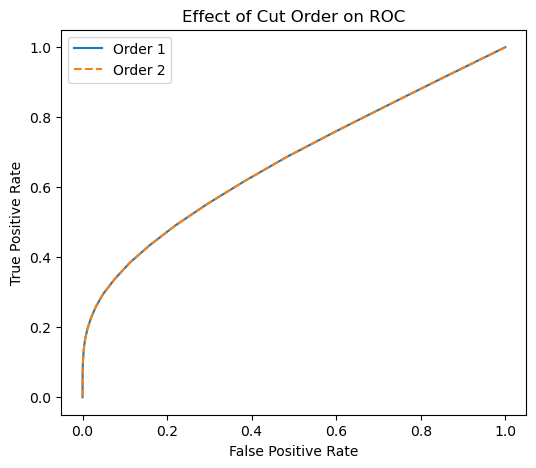

In [51]:
#Excerise 7.4

# Same cuts, but different order

cuts_order1 = [(VarNames[9], 0.5, "greater"),(VarNames[2], 0.3, "greater")]

cuts_order2 = [(VarNames[2], 0.3, "greater"),(VarNames[9], 0.5, "greater")]

# Use the same variable for comparison
var_to_plot = VarNames[9]

compare_cut_order(df_sig, df_bkg, cuts_order1, cuts_order2, var_to_plot, mode="greater")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [56]:
#Excerise 8.1

features = VarNames[9:]  # excluding signal column

# Convert to numpy arrays
X_sig = df_sig[features].values
X_bkg = df_bkg[features].values

# Compute mean vectors,I used axis=0 because I want mean of each feature
m1 = np.mean(X_sig, axis=0)   # signal
m2 = np.mean(X_bkg, axis=0)   # background

# Between-class covariance SB, I reshaped vectors because matrix multiplication requires column vectors
diff = (m2 - m1).reshape(-1, 1)
SB = diff @ diff.T

# At first I thought of looping over each event, but that was slow,so I used matrix operations instead
# Center data
X_sig_centered = X_sig - m1
X_bkg_centered = X_bkg - m2

SW = (X_sig_centered.T @ X_sig_centered) + (X_bkg_centered.T @ X_bkg_centered)

# I printed shapes first just to make sure everything is correct
print("SB shape:", SB.shape)
print("SW shape:", SW.shape)

SB shape: (10, 10)
SW shape: (10, 10)


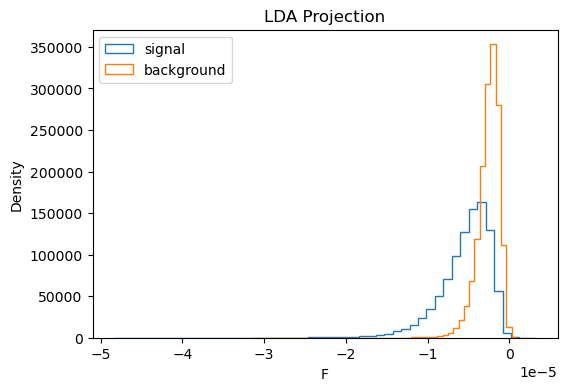

In [57]:
#Excerise 8.2

# Compute w
# I used np.linalg.pinv instead of inv in case SW is singular
w = np.linalg.pinv(SW) @ (m2 - m1)

# Compute projection Fn = w^T x
F_sig = X_sig @ w
F_bkg = X_bkg @ w

# Plot distributions
plt.figure(figsize=(6,4))

plt.hist(F_sig, bins=50, density=True, histtype="step", label="signal")
plt.hist(F_bkg, bins=50, density=True, histtype="step", label="background")

plt.xlabel("F")
plt.ylabel("Density")
plt.title("LDA Projection")
plt.legend()

plt.show()

AUC for F: -0.178


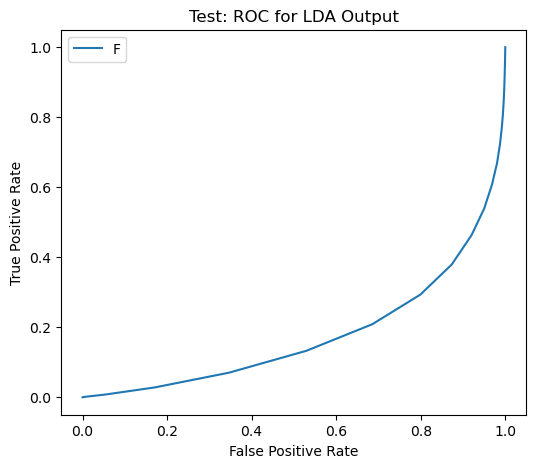

In [58]:
# Excerise 8.3

# Compute ROC
fpr, tpr = compute_roc(F_sig, F_bkg, mode="greater")

# Compute AUC for reference
auc = np.trapz(tpr, fpr)
print("AUC for F:", round(auc, 3))

# Plot
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="F")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test: ROC for LDA Output")
plt.legend()

plt.show()

In [69]:
# Excerise 8.4

# I tested all scenarios from Exercise 5

xc_vals, sig_vals = compute_significance(F_sig, F_bkg, Ns, Nb)

max_sig = np.max(sig_vals)

print(f"Scenario Ns={Ns}, Nb={Nb}")
print(f"Max significance: {round(max_sig,3)}\n")

Scenario Ns=10, Nb=100
Max significance: 0.953

